# ER131 Final Project Template
Fall 2025

# Predicting PG&E Feeder Level Congestion; Cui, Eichenlaub, Healy, Tikson

In this cell, replace the text above with your project title.  Then give an alphabetical (by last name) list of student group members.  Beside each student's name, provide a description of each student's contribution to the project, and an estimate of the number of hours each student put into the effort.  

# Background information (delete this markdown cell in your final submission)

## How to use this notebook: 
* Follow the format and sequencing of sections
* Edit the markdown cells to be specific to your project.
* Put the code you use to accomplish the tasks of each section in between each markdown cell.
* Delete this cell before you hand in the notebook
* As with homeworks, you'll hand in a `.ipynb` file and an `.html` file; we'll also ask you to make your data available. 

## Basic Project Requirements:

This notebook is the template for your semester project.  Each markdown cell provides instructions on what to do in order to complete a successful project.  The cell you're reading right now is the only one you can delete from what you eventually hand in.  For the other cells:
1. You may replace the instructions in each cell with your own work but do not edit the cell titles (with the exception of the project title, above).  
2. Follow the instructions in each section carefully.  For some sections you will enter only markdown text in the existing cells. For other sections, you'll accompany the markdown cells with additional code cells, and perhaps more markdown, before moving on to the next section.  

**Number of prediction questions:**  The number of prediction questions must be greater than or equal to $N_s-1$, the number of students in the team minus one.  (Two prediction questions are different if they use different target variables.) For example, a 3 person team would need to examine $3-1 = 2$ questions.  Questions should be related, but have distinct work efforts, interpretation and analysis. An example: for land use regression, you could have a core prediction question (what is pollution concentration on a fine spatial scale), a supporting question that explore how the degree of spatial aggregation influences prediction quality, plus a prediction model that explores *temporal* prediction at one point in space.  There is a lot of flexibility here; if you have any doubt about whether your questions are distinct, consult with the instructors.

**Number of models**: For each prediction question (target variable) you must train and evaluate the performance of three different machine learning models. E.g. for regression, you could do OLS, lasso, and regression tree.

**Data requirements**:  Projects must use data from a minimum of three different sources for groups of four, or two data sources for groups of less than four.  You must *merge* at least two data sets. </font>

**Group composition:** 
* Groups must be all undergraduate or all graduate students. That is, no mixing of graduate and undergraduate students.
* Undergraduate groups must be four people; Graduate student groups can be smaller with permission.   
* We recommend that you have a mix of students from across colleges / majors (e.g. CNR, CS, Data Science, Engineering, L&S).   

**Grading**.  You'll see point allocations listed in each of the section titles below.  In addition, there are other categories for points: 
1. Abstract (5 points).
2. Project backround (5 points).
3. Project objective (5 points).
4. Data description (5 points).
5. Data cleaning (10 points).
6. EDA (10 points).
7. Forecasting and Prediction Modeling (25 points).
8. Interpretation and Conclusions (20 points).
2. Visualization (10 points).  Plots should be well organized, legible, labelled, and well-suited for the question they are being used to answer or explore. 
2. Clarity (5 points). Note that clarity also supports points elsewhere, because if we can't understand what you're explaining, we'll assume you didn't understand what you were doing and give points accordingly!  

For each Section or Category, we will give points according to the following percentage scale:
1. More than 90%:  work that is free of anything but superficial mistakes, and demonstrates creativity and / or a very deep understanding of what you are doing.
2. 80-90%: work without fundamental errors and demonstrates a basic understanding of what you're doing.
3. 60-80%: work with fundamental flaws in the analysis and / or conveys that you do not understand the basics of the work you are trying to do.
4. Below 60%: Work that is severely lacking or incomplete.  

Note that we distinguish *mistakes* from *"my idea didn't work"*.  Sometimes you don't know if you can actually do the thing you're trying to do and as you dig in you find that you can't.  That doesn't necessarily mean you made a mistake; it might just mean you needed more information.  We'll still give high marks to ambitious projects that "fail" at their stated objective, as long as that objective was clear and you demonstrate an understanding of what you were doing and why it didn't work.

**Starting data**: To help contain your scope early on, we are providing you with several data sets to start your journey with.  Please go to the `project` in datahub; each folder contains a different starter notebook and data. 

**Additional suggested data sets**: See the last markdown cell of this notebook for some suggestions.

**A few other guiding remarks**
* The notebook should tell the story of your modeling and learning experience. We’ve set up the outline to help you do this.  Think about the overall arc of your project and use the notebook to explain the most important aspects of your thinking and what you’ve learned.  Make time to take a step back from the individual parts of the notebook to think about how it flows as a complete document.
* Markdown cells, not code cells, are where you convey your thinking and methodology. 
* We won’t read your code cells to understand your thinking or methods
* We will only use your code cells to verify your workflow
* Less is more when it comes to code output and visualizations. Any output should serve a purpose for the reader of the notebook, and you should make that purpose clear in your markdown cells.  For example: 
* Don’t display every line of a dataframe; use `.head()` or printouts of specific parts of a dataframe judiciously. Display contents of a dataframe when you want to show the reader something specific, and explain your thinking in a markdown cell.
* Use visualizations to tell your story, but make sure you explain in markdown cells what’s important about your visualizations. If you can’t tell the reader what’s important about the visualization, leave it out!
* Suppress output of functions unless it is crucial to explain your thinking and demonstrate your workflow.
* Generally, the notebook should not contain copious amounts of data, function outputs, plots. Think of your notebook as a giant function with a `verbose` argument…I want verbose = FALSE.


## Abstract (5 points)
Although this section comes first, you'll write it last.  It should be a ~250 word summary of your project.  1/3rd of the abstract should provide background, 1/3rd should explain what you did, and 1/3rd should explain what you learned.

## Project Background (5 points)
California’s electric grid is undergoing a rapid transformation driven by electricity demand––which is growing for the first time in over a decade––and the accelerated adoption of distributed energy resources (DERs) along with electric products such as electric vehicles (EVs) and heat-pumps. Much of this growth is occurring within the distribution system, which was historically designed for one way power flows and predictable load growth. Rapid load growth due to electrification, paired with two-way power flow systems which export energy in addition to importing it, are key contributors to today’s distribution-grid congestion. This poses a serious challenge for California’s electrification goals and prevents utilities from interconnecting DERs at an acceptable pace. 

Export-driven congestion (i.e. ‘generation congestion’) is especially salient in the Pacific Gas & Electric (PG&E) territory, where rooftop solar and community scale solar projects have been growing quickly. On certain feeders, mid-day exports from large numbers of solar customers already push circuits toward their hosting-capacity limits. When a feeder approaches its generation headroom constraints, PG&E may be unable to interconnect additional solar customers without costly upgrades. Moreover, mid-day generation congestion can lead to solar project curtailment, resulting in wasted energy. 

The primary tool that stakeholders use to understand these constraints today is the Integration Capacity Analysis (ICA) map. ICA provides a snapshot of generation hosting capacity, but it has some limitations. First, ICA represents only current conditions, and is not useful for identifying which where constraints may emerge in future years under growing DER adoption. Second, generating ICA values required PG&E to run computationally intensive engineering models that have little scalability. This makes it difficult for utilities or regulators to re-run ICA projections to produce iterative scenario-based estimates. These limitations create a gap for decision-makers , who lack the ability to forecast where hosting-capacity constraints are likely to emerge. Regulators and program administrators at organizations like Community Choice Aggregators and the California Energy commission implement various programs meant to improve DER adoption and grid health–such as behind-the-meter battery storage programs and load shifting programs, yet maximizing the value of these programs depends on understanding where the grid is most vulnerable.

In this context, a simple and computationally efficient predictive model of feeder-level generation congestion could provide meaningful value to PG&E, regulators, and program administrators. By using readily available inputs, such as load shapes, climate zone characteristics, and EV/DER adoption patterns, such a model can approximate where peak generation is likely to exceed feeder capabilities under future or varied scenarios.  While a simple predictive model could not replace PG&E’s internal engineering studies, it can serve as a complementary tool to identify feeders which may be under stress in future scenarios, using forecasted feature data. The model outputs could be used to strategically target load-shifting and battery storage programs, which help the distribution grid unlock more capacity without making physical infrastructure upgrades. 

California’s experience with flexible load programs emphasizes this need. Statewide programs, like managed EV charging pilots and the Demand Side Grid Support program, have historically struggled with locational targeting. In many cases, programs have underperformed, in part, because enrollment was not targeted to feeders with the most need. A predictive congestion model that identifies feeders likely to face future stress could therefore enable more impactful and cost-effective deployment of these programs.  



## Project Objective (5 points)
In this section you will pose the central objective or objectives for your semester project.  Objectives should be extremely clear, well-defined and clearly cast as forecasting problems.  

Some example questions: 
1. *"The purpose of this project is to train and evaluate different models to predict soil heavy metal contamination levels across the state of Louisiana, using a variety of features drawn from EPA, the US Census, and NAICS databases."* or
2. *"The purpose of this project is to train and evaluate different models to predict 1-minute generation from a UCSD solar PV site, up to 2 hours into the future, using historical data as well as basic weather forecast variables.*" or
3. *"The purpose of this project is to forecast daily emergency room visits for cardiac problems in 4 major US cities, using a majority of features including air quality forecasts, weather forecasts and seasonal variables."*

You should reflect here on why it's important to answer these questions.  In most cases this will mean that you'll frame the answers to your questions as informing one or more *resource allocation* problems.  If you have done a good job of providing project background (in the cell above) then this reflection will be short and easy to write.

**Comment on novelty:** You may find it hard to identify a project question that has *never* been answered before.  It's ok if you take inspiration from existing analyses.  However you shouldn't exactly reproduce someone else's analysis.  If you take inspiration from another analyses, you should still use different models, different data, and so on.

## Input Data Description (5 points)
Here you will provide an initial description of your data sets, including:
1. The origins of your data.  Where did you get the data?  How were the data collected from the original sources?  You must provide enough information for the reader to be able to access the data themselves.  
2. The structure, granularity, scope, temporality and faithfulness (SGSTF) of your data.  To discuss these attributes you should load the data into one or more data frames (so you'll start building code cells for the first time).  At a minimum, use some basic methods (`.head`, `.loc`, and so on) to provide support for the descriptions you provide for SGSTF. 
3. You should also describe which data fields you will use as your target variables, and which you will use as features.  

# Weather Data

### WeatherData Description (Solar radiation / Wind speed / Air temperature): 

The weather data used in this study were obtained from the California Irrigation Management Information System (CIMIS) website (https://cimis.water.ca.gov/), which is operated by the California Department of Water Resources (DWR). CIMIS manages a statewide network of over 145 automated weather stations and was developed in 1982 by DWR in collaboration with the University of California, Davis (UC Davis). The primary purpose of CIMIS is to support efficient irrigation and water resource management; however, the meteorological variables it provides are also widely used for environmental and air quality research.

For this project, we downloaded hourly weather data including: Solar radiation, Wind speed and Air temperature

The data were accessed through the CIMIS web portal after logging into the system. Users can select specific stations, time ranges, and sensors before downloading the data in CSV format. To reduce download time and ensure only relevant information was collected, we selected only the required sensors for each station. Because the website allows downloading data for a maximum of five stations at a time, multiple CSV files were downloaded and then aggregated into a single dataset for further analysis.

To present the original dataset downloaded from CIMIS, we used one-sixth of the full dataset as a representative sample because the complete file exceeds 100 MB in size:


In [17]:
import pandas as pd
raw = pd.read_csv(
    "weather/cimis_raw_1.csv",
    skiprows=1,    # skip the "# ---------" line
    engine="python"
)

# First row (row 0) is the header line as a single string
header = raw.iloc[0, 0].split(",")

# Remaining rows are the data, each as a single comma-separated string
data = raw.iloc[1:, 0].str.split(",", expand=True)

# Assign column names
data.columns = header

# clean DataFrame
df = data

df.head(10)

,Stn Id,Stn Name,CIMIS Region,Date,Hour (PST),Jul,Sol Rad (Ly/day),qc,Air Temp (F),qc,Wind Speed (mph),qc
1,2,FivePoints,San Joaquin Valley,1/1/2024,0100,001,0,,47.5,,2.6,
2,2,FivePoints,San Joaquin Valley,1/1/2024,0200,001,0,,46.7,,3.3,
3,2,FivePoints,San Joaquin Valley,1/1/2024,0300,001,0,,46.9,,4.3,
4,2,FivePoints,San Joaquin Valley,1/1/2024,0400,001,0,,45.5,,2.6,
5,2,FivePoints,San Joaquin Valley,1/1/2024,0500,001,0,,44.7,,2.4,
6,2,FivePoints,San Joaquin Valley,1/1/2024,0600,001,0,,45.1,,2.4,
7,2,FivePoints,San Joaquin Valley,1/1/2024,0700,001,1,,44.1,,2.6,
8,2,FivePoints,San Joaquin Valley,1/1/2024,0800,001,48,,43.8,,2.8,
9,2,FivePoints,San Joaquin Valley,1/1/2024,0900,001,92,,47.0,,7.1,
10,2,FivePoints,San Joaquin Valley,1/1/2024,1000,001,225,,49.4,,9.5,


#### Weather Data Structure:

The dataset is organized in a tabular format where each row represents one weather observation and each column represents a specific variable. The columns include:

-Stn Id (station identifier)<br>
-Stn Name (station name)<br>
-CIMIS Region (geographic region)<br>
-Date (calendar date of observation)<br>
-Hour (PST) (hourly timestamp in Pacific Standard Time)<br>
-Jul (Julian day indicator)<br>
-Sol Rad (Ly/day) (solar radiation)<br>
-Air Temp (F) (air temperature in Fahrenheit)<br>
-Wind Speed (mph) (wind speed in miles per hour)<br>
-Several qc columns that represent data quality control flags

For example, in the first row, Station 2 (FivePoints) recorded weather conditions on 1/1/2024 at 01:00 PST with an air temperature of 47.5°F and wind speed of 2.6 mph.

#### Weather Data Granularity / Scope / Temporality:

The granularity of the dataset is hourly, station-level measurements (which include all active stations in California) from 1/1/2024 - 12/31/2024.
Each row corresponds to:

-One specific station (e.g., FivePoints)<br>
-One specific date<br>
-One specific hour


In [18]:
df[
    (df['Sol Rad (Ly/day)'] == "") |
    (df['Wind Speed (mph)'] == "") |
    (df['Air Temp (F)'] == "")
]

,Stn Id,Stn Name,CIMIS Region,Date,Hour (PST),Jul,Sol Rad (Ly/day),qc,Air Temp (F),qc,Wind Speed (mph),qc
2580,2,FivePoints,San Joaquin Valley,4/17/2024,1200,108,1222,,,S,3.6,
6474,2,FivePoints,San Joaquin Valley,9/26/2024,1800,270,,M,,M,,M
10890,5,Shafter,San Joaquin Valley,3/28/2024,1800,088,,M,,M,,M
12404,5,Shafter,San Joaquin Valley,5/30/2024,2000,151,,M,,M,,M
13555,5,Shafter,San Joaquin Valley,7/17/2024,1900,199,,M,,M,,M
...,...,...,...,...,...,...,...,...,...,...,...,...
287562,113,King City-Oasis Rd.,Monterey Bay,9/26/2024,1800,270,,M,,M,,M
288187,113,King City-Oasis Rd.,Monterey Bay,10/22/2024,1900,296,,M,,M,,M
293492,114,Arroyo Seco,Monterey Bay,5/30/2024,2000,151,,M,,M,,M
296346,114,Arroyo Seco,Monterey Bay,9/26/2024,1800,270,,M,,M,,M


#### Weather Data Faithfulness:

The data originate from the California Irrigation Management Information System (CIMIS), a government-operated and scientifically maintained network of automated weather stations. This makes the dataset highly reliable and faithful to real-world conditions.

Also, the presence of qc (quality control) columns indicates that the data undergo validation, increasing trustworthiness.

As expected for sensor-based data collected over long time periods, the dataset contains explicitly flagged missing values, denoted by the code “M” in the Solar Radiation, Air Temperature, and Wind Speed columns. These missing values occur across multiple stations and dates, indicating that the gaps are likely due to system-wide outages, sensor downtime, or data validation failures.

### Electric Vehicles (EVs) adoption (2023 / 2024 / YoY / %change): 

We use ZIP-code–level electric vehicle adoption data from the California Energy Commission’s ZEV Statistics Dashboard (https://www.energy.ca.gov/zevstats), which provides annual DMV-verified counts of registered Battery Electric Vehicles (BEVs) and Plug-in Hybrid Electric Vehicles (PHEVs). We filtered for 2023 and 2024 as well as BEV and PHEV categories, and calculated total EVs per ZIP as well as absolute and percentage growth from 2023→2024. These steps were implemented within excel to create a dataframe ready to merge with other data. During the merge step, ZIP codes were standardized to five-digit strings, duplicates were removed, and columns were renamed to align with our main dataframe.
Structurally, this dataset is a simple tabular snapshot with one row per ZIP code. It is coarse relative to feeder boundaries but provides a useful indicator of EV adoption trends that contribute to long-term load growth. The data update annually, so we treat EV counts as slow-changing structural features rather than time-varying signals. These EV variables represent just one of several feature groups used in our model alongside weather, DER penetration, feeder characteristics, and load-shape features. Our response variable (feeder headroom and congestion risk) is described separately.

# Integration Capacity Analysis Data


## Origins of Integration Capacity Analysis Data
The Integration Capacity Analysis (ICA) data come from Pacific Gas and Electric Company’s (PG&E) GRIP hosting capacity portal: https://grip.pge.com/
PG&E publishes hosting capacity results as part of its obligations under the CPUC’s Distribution Resource Planning (DRP) proceeding. These data provide generation hosting capacity values per feeder line-section and month-hour 
To obtain feeder hosting capacity data:
1. Navigate to PG&E’s ICA hosting capacity dataset portal
2. Download all Division ZIP files, each representing a PG&E operating division
(e.g., North Valley.zip, San Francisco.zip, Peninsula.zip, etc.)
3. Each division ZIP contains hundreds of feeder-level ZIP archives.

Each feeder ZIP contains a single CSV with hourly ICA values for all line sections on that feeder.
1. The origins of your data.  Where did you get the data?  How were the data collected from the original sources?  You must provide enough information for the reader to be able to access the data themselves.  
2. The structure, granularity, scope, temporality and faithfulness (SGSTF) of your data.  To discuss these attributes you should load the data into one or more data frames (so you'll start building code cells for the first time).  At a minimum, use some basic methods (`.head`, `.loc`, and so on) to provide support for the descriptions you provide for SGSTF. 
3. You should also describe which data fields you will use as your target variables, and which you will use as features.  

To obtain feeder line shapefiles:
1. Navigate to PG&E’s ICA hosting capacity dataset portal
2. Download 'GRIP Shape' files

To obtain feeder charachteristics/metadata:
1. Navigate to PG&E’s ICA hosting capacity dataset portal
2. Click "system" on left side pane
3. Click on the three dots next to "Distribution lines" under "system" menu
4. Click "add to table"
5. Download


## ICA Data Structure, Granularity, Scope, Temporality
The ICA line section dataset is structured as one CSV per feeder, where each CSV contains rows for every line section on that feeder. Each row corresponds to a unique combination of:
- month (1–12)
- hour (0–23)
- loading_scenario (e.g., 10th, and 90th percentile case)
- loadorgen (“G” for generation, “L” for load)
- ICA limit values, such as hourly_ica_sg or hourly_ica_of
- Line Section ID

### Temporality
The ICA data is reported by month hour, at the 90th and 10th pctl. This means each row represents the 90th/10th percentile conditions more that line section during a particular month hour, aggregated accross
all days in that month

### Granularity
The ICA data is bery granular, with one row per line section. Each feeder can have hundreds of line sections. 

In [5]:
import zipfile, glob
import pandas as pd
from io import BytesIO

division_zip = "ica_data/raw_zips/Yosemite.zip"

with zipfile.ZipFile(division_zip, "r") as div_zip:
    inner = [f for f in div_zip.namelist() if f.endswith(".zip")]
    raw_bytes = div_zip.read(inner[0])

    with zipfile.ZipFile(BytesIO(raw_bytes), "r") as feeder_zip:
        csv_name = [f for f in feeder_zip.namelist() if f.endswith(".csv")][0]
        df_raw = pd.read_csv(feeder_zip.open(csv_name))

print(df_raw.head(4))

   LineSectionID LoadOrGen  Month  Hour  Loading_Scenario  IC_Thermal_kW  \
0        3032364         G      1     0                90           3610   
1        3032364         G      1     0                10           3600   
2        3032364         G      1     1                10           3600   
3        3032364         G      1     1                90           3610   

   IC_Voltage_kW  IC_Protection_kW IC_Safety_kW Hourly_ICA_OF Hourly_ICA_SG  \
0            570           12000.0     REDACTED      REDACTED           570   
1            370           12000.0     REDACTED      REDACTED           370   
2            360           12000.0     REDACTED      REDACTED           360   
3            550           12000.0     REDACTED      REDACTED           550   

  Monthly_ICA_SG  Hourly_Load IC_Safety_Bank_kW IC_Safety_Opflex_kW  
0       REDACTED          NaN          REDACTED            REDACTED  
1       REDACTED          NaN          REDACTED            REDACTED  
2       REDAC

## Data Cleaning (10 points)
In this section you will walk through the data cleaning and merging process.  Explain how you make decisions to clean and merge the data.  Explain how you convince yourself that the data don't contain problems that will limit your ability to produce a meaningful analysis from them.   

#### Basic Data Aggregation Principles:

Our data were derived from multiple sources that varied widely in both granularity and scope. To ensure consistency with our prediction objective, we defined our temporal scope as month–hour intervals from January 1, 2024, to December 31, 2024, and our geographic scope as the PG&E service territory. Accordingly, all datasets were aggregated to the month–hour level where necessary. Some datasets were already available at this resolution and required no transformation, while EV data were only available at the annual level and were therefore repeated across all month-hours within each zip code.

At the geographic level, our target variable and several predictors from the ICA dataset were available at the feeder level, while other datasets were provided at the ZIP code or station level (e.g., CIMIS weather data). To align these spatial scales, ZIP code–level data were assigned to all feeders within the same ZIP code, and station-level data were mapped to ZIP codes using the nearest weather station for each ZIP code.

### Cleaning and Validating CIMIS Data:

To match the temporal structure of the modeling dataset, which operates at the month–hour level, the original hourly CIMIS observations were aggregated by computing average values for each month–hour combination (for example, the average of all observations at 2:00 PM in January for a specific CIMIS station). 

Spatially, CIMIS data are reported at individual weather stations rather than at the feeder level. Because latitude and longitude coordinates were available for each CIMIS station, and a PG&E territory ZIP code shapefile was available, spatial aggregation was performed using geographic proximity. Each CIMIS station was spatially joined to a ZIP code using its coordinates, and for each ZIP code the nearest station was identified. The resulting month–hour weather variables were then assigned to all feeders located within the corresponding ZIP code. This ensured that each feeder was associated with representative local weather conditions while maintaining geographic consistency across the PG&E territory.

Following these cleaning, aggregation, and spatial alignment steps, the final CIMIS dataset provided complete and spatially consistent month–hour profiles of solar radiation, air temperature, and wind speed for use as continuous predictors in the headroom prediction models.

For some CIMIS stations, missing values were present for specific hours and for one or more weather sensors. These rows were not removed during the cleaning process, as doing so would have created temporal gaps in the month–hour weather profiles and reduced data coverage across the study period. Instead, missing values were handled during the modeling stage. Specifically, indicator variables (via dummy encoding) were created for missing entries, and the corresponding values were imputed using average conditions. This approach preserved the completeness of the dataset while minimizing potential bias introduced by missing sensor readings.

After cleaning and merging, the weather_ready_to_merge looks like:

In [ ]:
import pandas as pd

df = pd.read_csv("weather/2024_weather_cleaned.csv")
df.head()

,ZIP_CODE,Month,Hour,Sol Rad (Ly/day),Air Temp (F),Wind Speed (mph)
0,90001,1,100,0.000,53.826,2.623
1,90001,1,200,0.000,53.621,2.629
2,90001,1,300,0.000,53.537,2.394
3,90001,1,400,99.619,53.247,2.484
4,90001,1,500,13.905,53.242,2.745


### Cleaning and Validating EV Data:

We use ZIP-code–level electric vehicle (EV) adoption data from the California Energy Commission’s ZEV Statistics Dashboard, which provides annual, DMV-verified counts of registered Battery Electric Vehicles (BEVs) and Plug-in Hybrid Electric Vehicles (PHEVs). The dataset was filtered for the 2023 and 2024 calendar years and restricted to BEV and PHEV categories. For each ZIP code, we computed total EV counts as well as absolute and percentage growth from 2023 to 2024. These preprocessing steps were conducted in Excel to create a clean tabular dataset ready for integration with the modeling pipeline. During the merge process, ZIP codes were standardized to five-digit strings, duplicate records were removed, and column names were harmonized to match the main modeling dataset.

Structurally, this dataset consists of a single annual snapshot with one row per ZIP code. Because the EV data are only available at the annual level, the values were repeated for every corresponding month–hour observation within each ZIP code when merged with the feeder-level dataset. As a result, EV adoption is treated as a slow-changing structural feature rather than a time-varying signal. Although spatially coarser than feeder boundaries, the EV variables provide an important indicator of long-term load growth and electrification pressure.

After cleaning and merging, the EV_ready_to_merge looks like:


In [ ]:
import pandas as pd

df = pd.read_csv("EV_Pop_Growth_23_24.csv")
df.head()

,Zip Code,2023,2024,YoY Change,%change
0,89061,1.0,1.0,0,0.000000
1,90001,295.0,449.0,154,0.522034
2,90002,253.0,396.0,143,0.565217
3,90003,318.0,507.0,189,0.594340
4,90004,1775.0,2241.0,466,0.262535




1.	Climate Zones and ZIP Code Cleaning
The merge pipeline begins by loading California Building Climate Zone shapefiles and ZIP code boundary shapefiles. Both datasets were converted into a shared coordinate reference system to ensure spatial comparability. A spatial intersection was performed to determine which climate zone overlapped most with each ZIP code. ZIPs were assigned to the climate zone with the largest intersecting area instead of centroid, since ZIP shapes are often irregular. The resulting ZIP–climate mapping was validated by verifying that each ZIP received exactly one climate zone assignment and that the set of climate zone labels matched CALMAC documentation. 

2.	CALMAC Load Shape Cleaning
CALMAC residential load shapes were provided as hourly time series for 160 GP profiles. Timestamps were parsed into datetime objects, and hour and month fields were extracted to match the temporal structure of the ICA data. The dataset was then aggregated to gp × month × hour by computing average hourly consumption within each group. Climate zone assignments were merged into this dataset so that only GP profiles corresponding to the assigned climate zone for each ZIP were retained. Consistency checks confirmed that the aggregated table contained the expected number of gp × month × hour combinations and that the climate zone mapping aligned with CALMAC descriptions.

3.	Feeder Shapefile Cleaning and ZIP Assignment
Feeder polygons from PG&E’s FeederDetail_Voltage shapefile were loaded and feederIDs were normalized to remove any leading zeros or extra spacing.  A spatial overlay was used to assign each feeder to the ZIP code representing the largest area of overlap. Approximately two-thirds of feeder polygons did not intersect any ZIP boundary in the shapefile. The definitive reason for this is unknown, but we assume that the missing feeders were in rural areas with low population, and therefore may not have a zip code. However, all feeders that appeared in later merges were successfully assigned ZIP codes, confirming that ZIP assignment was not a source of missing feeders.

4.	Constructing the Feeder Load Matrix
The ZIP–GP lookup was merged with the aggregated CALMAC load shapes to produce feeder–GP–month–hour observations. This dataset was pivoted wide to create one row per feeder × month × hour with one column per GP. GP columns were then summed to compute a single aggregated hourly load value for each feeder–month–hour. This produced a consistent structure for merging with ICA and other features and ensured that non-overlapping GP profiles did not create irregular row counts.

5.	EV Data Cleaning and Merge
ZIP-level EV adoption data for 2023 and 2024 were prepared externally by selecting Battery Electric Vehicle and Plug-in Hybrid Electric Vehicle categories, calculating year-over-year absolute and percentage change, and standardizing ZIP codes to five-digit strings. Duplicates were removed, and column names were matched to the main dataset. During the merge, ZIP codes were normalized in both datasets to prevent mismatch due to inconsistent string formatting.

6.	ICA Data Cleaning and Validation
ICA data arrived in the form of PG&E “division ZIPs,” each containing hundreds of feeder-specific ZIP files. Each inner ZIP held a CSV representing hourly hosting capacity for each line section. Column names were normalized to lowercase and stripped of whitespace. Files missing required fields (month, hour, loadorgen, the selected ICA column) were skipped. Exploratory validation across tens of millions of rows showed that all ICA observations in the raw data were labeled as generation (“G”). No load rows contain headroom data, even when scanning both GICA and LICA file structures. This confirmed that load-side headroom could not be derived from the available data and that generation hosting capacity (hourly_ica_sg) was the only viable ICA measure.

ICA values were aggregated across line sections by computing the mean hosting capacity for each feederid × month × hour. Approximately 7.4% of month-hour combinations lacked any corresponding ICA rows in PG&E source files. Missingness checks showed no pattern across hours or months, indicating the gaps originate from PG&E’s dataset rather than the processing pipeline.

Feeder IDs extracted from ICA ZIP filenames were normalized by removing leading zeros and trimming whitespace. This normalization ensured that ICA feeder IDs aligned with those in the feeder shapefile and feeder_characteristics metadata file.

7.	Merging ICA, Feeder Metadata, and Weather
The aggregated ICA data were merged onto the feeder load matrix using feederid, month, and hour as keys. Rows with missing ICA were subsequently filtered out to create the final cleaned dataset. Feeder-level metadata from feeder_characteristics.csv was merged by normalizing both feederid columns and removing existing metadata columns to avoid duplicate suffixes. A validation step confirmed that all feeder-level metadata columns merged correctly after correcting for leading zeros in feeder IDs. Finally, weather data were cleaned by converting 100-, 200-, …-formatted hour stamps into 0–23 integers and merged on ZIP × month × hour.

8.	Final Validation
Several validation checks ensured the merged dataset was internally consistent. These included verifying that each feeder-month-hour key appeared only once, confirming that feeder IDs in the final dataset matched those in both ICA files and feeder metadata, and confirming that feeders had an expected distribution across PG&E service territory.




In [16]:
""" Goal: produce a feeder × month-hour feature matrix with:
- Load shape features (kWh per GP)
- EV adoption (via ZIP)
- Temperature (via ZIP or grid)
- ICA / feeder metadata (line rating, %res, %ind, %com, congestion Y/N)
"""

import pandas as pd
import geopandas as gpd
import glob
import os
import zipfile
from io import BytesIO

#remove leading '0's from feederid
def normalize_feederid(series):
    """
    Normalize feeder ids to a common key:
    - cast to string
    - strip whitespace
    - strip leading zeros ("001234" -> "1234")
    - map empty string to "0"
    """
    s = series.astype(str).str.strip()
    s_nozero = s.str.lstrip("0")
    return s_nozero.replace({"": "0"})

def load_feeder_characteristics(path="ica_data/feeder_characteristics.csv"):
    """
    Load feeder-level data, including DER capacity, customer mix, etc. and drop unneeded columns.

    """
    print("Loading feeder characteristics...")

    df = pd.read_csv(path)

    df.columns = df.columns.str.strip().str.lower()

    if "feederid" not in df.columns:
        raise ValueError("feeder_characteristics must contain a 'Feeder ID' column.")
    drop_cols = [
        "feeder_name",
        "substation name",
        "division",
        "last_update_on_map",
        "publish",
        "objectid",
        "nominal_voltage_kV", #this would probably be a strong predictor, but removing it for the transferrability of our model
        "redacted_data",
        "shape__length",

    ]
    drop_cols = [c for c in drop_cols if c in df.columns]
    df = df.drop(columns=drop_cols)

    
    df["feederid"] = normalize_feederid(df["feederid"])

    return df

def process_line_zips(
    input_dir, loading_scenario, ica_col, debug: bool = False,
):
    """
    Stream through PG&E division ZIPs and compute feeder-level
    ICA data.

    Returns a DataFrame with columns:
    ['feederid', 'month', 'hour', 'loadorgen', 'mean_ica_sg']
    """
    records = []

    # Find division-level ZIP files
    division_zips = glob.glob(os.path.join(input_dir, "*.zip"))
    if not division_zips:
        print(f"[ICA] No division ZIPs found in {input_dir}")
        return pd.DataFrame(columns=["feederid", "month", "hour", "loadorgen", "mean_ica_sg"])

    if debug:  # only process first division .zip in debug mode
        division_zips = division_zips[:1]

    for div_zip_path in division_zips:
        print(f"[ICA] Processing division zip: {os.path.basename(div_zip_path)}")
        with zipfile.ZipFile(div_zip_path, "r") as div_zip:
            for inner_name in div_zip.namelist():
                # Only process inner ZIPs
                if not inner_name.lower().endswith(".zip"):
                    continue

                # Get feederid from inner ZIP name (zip files hold line sections, title = feederID)
                feeder_id_raw = os.path.splitext(os.path.basename(inner_name))[0]
                # Handle names like 'GICA_102530401' - GICA = Generation data, LICA = Load data
                parts = feeder_id_raw.split("_")
                if len(parts) > 1:
                    feederid = parts[-1]
                else:
                    feederid = feeder_id_raw

                try:
                    inner_bytes = div_zip.read(inner_name)
                except KeyError:
                    print(f"[ICA] Warning: could not read {inner_name} in {div_zip_path}")
                    continue

                with zipfile.ZipFile(BytesIO(inner_bytes), "r") as feeder_zip:
                    csv_members = [
                        m for m in feeder_zip.namelist()
                        if m.lower().endswith(".csv")
                    ]
                    if not csv_members:
                        print(f"[ICA] Warning: no CSV in {inner_name}")
                        continue

                    csv_name = csv_members[0]
                    with feeder_zip.open(csv_name) as src:
                        df = pd.read_csv(src)

                # Standardize columns
                df.columns = df.columns.str.strip().str.lower()

                # Ensure ICA column exists
                if ica_col not in df.columns:
                    print(f"[ICA] Warning: '{ica_col}' not found in {csv_name}; skipping this file")
                    continue

                # Ensure required grouping columns exist
                required_group_cols = ["month", "hour", "loadorgen"]
                missing = [c for c in required_group_cols if c not in df.columns]
                if missing:
                    print(f"[ICA] Warning: missing {missing} in {csv_name}; skipping this file")
                    continue

                # Filter by loading scenario (e.g., 90th percentile)
                if "loading_scenario" in df.columns and loading_scenario is not None:
                    df = df[df["loading_scenario"] == loading_scenario].copy()

                # Drop monthly_ica_sg if present
                if "monthly_ica_sg" in df.columns:
                    df = df.drop(columns=["monthly_ica_sg"])

                # Attach feederid
                df["feederid"] = feederid

                # Coerce ICA column to numeric and drop NAs
                df[ica_col] = pd.to_numeric(df[ica_col], errors="coerce")
                df = df.dropna(subset=[ica_col])
                if df.empty:
                    continue

                group_cols = ["feederid", "month", "hour", "loadorgen"]

                # Aggregate across line sections to feeder-level mean
                grouped = (
                    df.groupby(group_cols, as_index=False)[ica_col]
                      .mean()
                      .rename(columns={ica_col: "mean_ica_sg"})
                )

                records.append(grouped)

    if not records:
        raise ValueError("[ICA] No ICA values computed from division ZIPs.")

    # First, concatenate all partial results
    feeder_ica = pd.concat(records, ignore_index=True)

    # Normalize feeder IDs
    feeder_ica["feederid"] = normalize_feederid(feeder_ica["feederid"])

    # Some feeders may appear in multiple files; aggregate again
    feeder_ica = (
        feeder_ica
        .groupby(["feederid", "month", "hour", "loadorgen"], as_index=False)
        .agg({"mean_ica_sg": "mean"})
    )

    print(
        f"[ICA] Computed feeder-level ICA for "
        f"{feeder_ica['feederid'].nunique()} feeders "
        f"across {feeder_ica['loadorgen'].unique().tolist()}."
    )

    return feeder_ica

def load_calmac_load_shapes():
    """
    Load CALMAC hourly load shapes. 160 total residential load shapes, 40 per climate zone.

    CSV shoudl contain [gp (load shape identifier), date, hour, kwh]
    """
    print("Loading residential electric load shapes from CALMAC/Res_GP_Elec_2024.csv...")
    load_data = pd.read_csv("CALMAC/Res_GP_Elec_2024.csv")
    return load_data


# Load spatial data
def load_climate_zones():
    """Load CEC building climate zones shapefile. 
    This is used to spacially map load shapes (GPs) and assign to correct ZIP code"""
    print("Loading climate zones...")
    climate_zones = gpd.read_file("CALMAC/Building_Climate_Zones.shp")
    return climate_zones

def load_zip_polygons():
    """Load ZIP code polygons shapefile. Used to determine which ZIPs/Climate zones belong together"""
    print("Loading ZIP polygons...")
    zips = gpd.read_file("zip_codes/zip_poly.shp")
    return zips

    
def load_feeder_shapes():
    """
    Load feeder shapefile. Used to Join with ZIP codes.
    """
    print("Loading feeders...")
    feeders = gpd.read_file("ica_data/FeederDetail_Voltage.shp")  
    feeders["feederid"] = normalize_feederid(feeders["feederid"])
    return feeders

# Map ZIP -> climate zone --> GP list
def map_climate_zones(climate_zones: gpd.GeoDataFrame) -> gpd.GeoDataFrame:
    """
    CALMAC documentation says which Climate Zones correspond to their 4 PG&E service territories.
    Add CALMAC climate zone (extracted from (GP)) labels to CEC climate zones.
    """
    print("Mapping climate zones to CALMAC groups...")
    cz_groups = {
        1: "Coastal", 3: "Coastal", 5: "Coastal",
        2: "Inland", 4: "Inland",
        11: "North Central Valley", 12: "North Central Valley",
        13: "South Central Valley",
    }

    climate_zones["BZone"] = climate_zones["BZone"].astype(int)
    climate_zones["cz_groups"] = climate_zones["BZone"].map(cz_groups)
    return climate_zones


def process_zip_climate_mapping(zips: gpd.GeoDataFrame, climate_zones: gpd.GeoDataFrame) -> gpd.GeoDataFrame:
    """
    Assign each ZIP a climate zone group based on the CZ that has the largest overlap area.
    Returns a GeoDataFrame with ZIP geometry and cz_groups.
    """
    print("Processing ZIP → climate group mapping (majority-area overlay)...")
    # Ensure both layers are in the same CRS for area calculations
    zips = zips.to_crs(climate_zones.crs)

    # Intersect ZIP polygons with climate zone polygons to get overlap pieces
    zip_cz_overlap = gpd.overlay(
        zips,
        climate_zones[["cz_groups", "geometry"]],
        how="intersection",
    )

    # Compute area of each overlap piece
    zip_cz_overlap["overlap_area"] = zip_cz_overlap.geometry.area

    # For each ZIP, find the climate group with the largest overlapping area
    # Assumes ZIP_CODE uniquely identifies each ZIP polygon
    idx = zip_cz_overlap.groupby("ZIP_CODE")["overlap_area"].idxmax()
    majority = zip_cz_overlap.loc[idx, ["ZIP_CODE", "cz_groups"]]

    # Join the primary climate group back onto the original ZIP geometries
    zips_climate = zips.merge(majority, on="ZIP_CODE", how="left")
    zips_climate = zips_climate[zips_climate["cz_groups"].notna()].copy()
    return zips_climate  # has ZIP_CODE, geometry, cz_groups, etc.


def load_calmac_characteristics():
    """
    Load CALMAC residential and non-residential GP characteristics and
    return a combined DataFrame with 'gp' and climate zone columns.
    """
    print("Loading CALMAC characteristics...")
    res_chars = pd.read_csv("CALMAC/res_characteristics.csv")
    nonres_chars = pd.read_csv("CALMAC/nonres_characteristics.csv")

    res_chars["type"] = "residential"
    nonres_chars["type"] = "nonresidential"

    gps_all = pd.concat([res_chars, nonres_chars], ignore_index=True)
    return gps_all


def zip_gp_lookup(zips_climate: gpd.GeoDataFrame, gps_all: pd.DataFrame) -> pd.DataFrame:
    """
    Build a ZIP → GP lookup table no geometry.

    Steps:
    - Group GPs by CALMAC climate zone label (seg_cz)
    - Merge onto ZIPs by cz_groups (must match seg_cz labels: e.g. 'Coastal')
    - Explode GP lists so we get one row per ZIP–GP pair
    """
    print("Building ZIP → GP lookup (no geometry)...")

    # Group GPs by CALMAC segment climate zone, create list of relevant GPs per CZ
    gps_by_zone = gps_all.groupby("seg_cz")["gp"].apply(list).reset_index()
    gps_by_zone.rename(columns={"gp": "gp_list"}, inplace=True)

    # keep only necessary columns
    zips_small = zips_climate[["ZIP_CODE", "cz_groups"]].drop_duplicates()
    # zips_climate has a 'cz_groups' column,  match  to 'seg_cz'
    zip_gp = zips_small.merge(
        gps_by_zone,
        left_on="cz_groups",
        right_on="seg_cz",
        how="left"
    )

    zip_gp = zip_gp.drop(columns=["seg_cz"])

    # Explode gp_list to one row per ZIP–GP
    zip_gp = zip_gp.explode("gp_list").rename(columns={"gp_list": "gp"})

    print(f"ZIP–GP pairs: {len(zip_gp)}")
    return zip_gp  

# Aggregate KWH consumed across gp x month x hour
def aggregate_load_shapes():
    print("Loading CALMAC load shapes...")
    load_data = load_calmac_load_shapes()

    # Ensure date is datetime
    load_data["date"] = pd.to_datetime(load_data["date"])

    load_data["month"] = load_data["date"].dt.month

    # Aggregate to month-hour-gp
    load_month_hour = (
        load_data
        .groupby(["gp", "month", "hour"], as_index=False)
        .agg({"kwh": "mean"})  
    )

    print(
        f"Aggregated load rows: {len(load_month_hour)} "
        f"({load_month_hour['gp'].nunique()} GPs, "
        f"{load_month_hour['month'].nunique()} months, "
        f"{load_month_hour['hour'].nunique()} hours)"
    )
    return load_month_hour  # columns: gp, month, hour, kwh

# Map feeders to zips

def feeder_zips_map(feeders: gpd.GeoDataFrame, zips_climate: gpd.GeoDataFrame) -> gpd.GeoDataFrame:
    """Map each feeder to a ZIP using majority-area overlay."""
    print("Mapping feeders to ZIPs (majority-area overlay)...")

    # Ensure same CRS
    feeders = feeders.to_crs(zips_climate.crs)

    # Intersect feeder polygons with ZIP polygons to get overlap pieces
    feeder_zip_overlap = gpd.overlay(
        feeders[["feederid", "geometry"]],
        zips_climate[["ZIP_CODE", "geometry"]],
        how="intersection",
    )

    # Compute area of each overlap piece
    feeder_zip_overlap["overlap_area"] = feeder_zip_overlap.geometry.area

    # For each feeder, find the ZIP with the largest overlapping area
    idx = feeder_zip_overlap.groupby("feederid")["overlap_area"].idxmax()
    feeder_zip = feeder_zip_overlap.loc[idx, ["feederid", "ZIP_CODE"]]

    # Only one ZIP per feeder 
    feeder_zip_map = feeder_zip.reset_index(drop=True)

    print(f"Unique feeders mapped: {feeder_zip_map['feederid'].nunique()}")
    return feeder_zip_map

# Pivot wide - necessary to keep DF from exploding
def build_feeder_gp(zip_gp: pd.DataFrame, load_month_hour: pd.DataFrame, feeder_zip_map: pd.DataFrame) -> pd.DataFrame:
    """
    Build feeder-level load features. Final shape: one row per feederid, ZIP, month, hour)
    """
    print("Building feeder × month-hour load features...")
    # keep only zips with feeders
    zips_for_feeders = feeder_zip_map["ZIP_CODE"].unique()
    zip_gp_sub = zip_gp[zip_gp["ZIP_CODE"].isin(zips_for_feeders)].copy()

    # Join ZIP → feeder to get feeder–ZIP–GP
    feeder_zip_gp = feeder_zip_map.merge(
        zip_gp_sub,
        on="ZIP_CODE",
        how="left"
    )
    
    # feeder-gp pairs
    feeder_gp = (
        feeder_zip_gp[["feederid", "gp"]].dropna(subset=["gp"]).drop_duplicates()
    )
    print(f"Feeder-GP pairs: {len(feeder_gp)}")

    #join feeder-GP with loads
    feeder_gp_month_hour = feeder_gp.merge(
        load_month_hour,
        on="gp",
        how="left"
    )
    #pivot GP to columns: one row per feeder-month-hour
    feeder_wide = feeder_gp_month_hour.pivot_table(
        index=["feederid", "month", "hour"],
        columns="gp",
        values="kwh",
        aggfunc="mean", #shouldn't be duplicates, but pivot_wide requires an aggfunc
        #GPs that don't belong to a feeder will be "NaN"
    ).reset_index()

    # flatten GP columns, rename kwh_gp
    feeder_wide.columns = [
        f"kwh_{c}" if isinstance(c, str) and not c in {"feederid", "month", "hour"} else c
        for c in feeder_wide.columns
    ]

    # Sum across all kwh_* columns to get a single load shape per feeder-month-hour
    gp_cols = [c for c in feeder_wide.columns if isinstance(c, str) and c.startswith("kwh_")]
    feeder_wide["load"] = feeder_wide[gp_cols].sum(axis=1)

    # Keep only aggregated load plus keys
    feeder_wide = feeder_wide[["feederid", "month", "hour", "load"]]

    # Merge ZIP_CODE back in
    feeder_wide = feeder_wide.merge(
        feeder_zip_map,
        on="feederid",
        how="left"
    )

    print(f"Feeder-wide feature rows: {len(feeder_wide)} with aggregated load shape")
    return feeder_wide

def load_ev_data(ev_path: str = "EV_Pop_Growth_23_24.csv") -> pd.DataFrame:
    """
    Load EV adoption data and normalize ZIP code.

    Expects a column 'Zip Code' in the CSV.
    Returns a DataFrame with a standardized 'ZIP_CODE' column.
    """
    print("Loading EV data...")
    ev = pd.read_csv(ev_path)

    # Normalize ZIP codes to 5-char str
    ev["Zip Code"] = (
        ev["Zip Code"]
        .astype(str)
        .str.strip()
        .str.zfill(5)
    )

    # Drop duplicate ZIPs 
    ev_unique = ev.drop_duplicates(subset=["Zip Code"]).copy()

    # Rename to match feeder_features
    ev_unique = ev_unique.rename(columns={"Zip Code": "ZIP_CODE"})

    print(f"Unique ZIPs in EV data: {ev_unique['ZIP_CODE'].nunique()}")
    return ev_unique
def attach_ev_to_feeders(feeder_features: pd.DataFrame, ev_df: pd.DataFrame) -> pd.DataFrame:
    """
    Merge ZIP-level EV data onto feeder_features (feeder × month × hour).

    - feeder_features: must have 'ZIP_CODE'
    - ev_df: must have 'ZIP_CODE' + EV columns

    Result: same number of rows as feeder_features, with EV columns added.
    """
    print("Merging EV data onto feeder_features...")

    # Normalize ZIP format in feeder_features 
    ff = feeder_features.copy()
    ff["ZIP_CODE"] = (
        ff["ZIP_CODE"]
        .astype(str)
        .str.strip()
        .str.zfill(5)
    )

    merged = ff.merge(
        ev_df,
        how="left",
        on="ZIP_CODE",
        suffixes=("", "_EV")  # EV side gets suffix if there are name conflicts
    )

    print(f"Rows before EV merge: {len(ff):,}")
    print(f"Rows after EV merge:  {len(merged):,}")
    return merged

def main(debug: bool = False):
    # Load  climate + ZIP
    climate_zones = load_climate_zones()
    climate_zones = map_climate_zones(climate_zones)

    zips = load_zip_polygons()
    zips_climate = process_zip_climate_mapping(zips, climate_zones)

    # 2. CALMAC GPs + ZIP to GP mapping
    gps_all = load_calmac_characteristics()
    zip_gp = zip_gp_lookup(zips_climate, gps_all)

    # 3. Aggregate CALMAC load shapes to gp × month × hour (May–Oct)
    load_month_hour = aggregate_load_shapes()

    # 4. Load feeders + map to ZIPs
    feeders = load_feeder_shapes()
    feeder_zip_map = feeder_zips_map(feeders, zips_climate)

    # 5. Build feeder × month-hour × GP load matrix
    feeder_features = build_feeder_gp(zip_gp, load_month_hour, feeder_zip_map)
    #6. Load EV data and merge onto feeder_features
    ev_df = load_ev_data()
    feeder_features = attach_ev_to_feeders(feeder_features, ev_df)

    feeder_ica = process_line_zips(
        input_dir="ica_data/raw_zips",
        loading_scenario=90,
        ica_col="hourly_ica_sg",
        debug=debug,
    )

    feeder_features = feeder_features.merge(
        feeder_ica,
        on=["feederid", "month", "hour"],
        how="left",
    )
    
    # 7. Load feeder-level metadata and merge onto every feeder × month × hour row
    feeder_chars = load_feeder_characteristics()

    # Ensure feederid is a normalized string key on both sides before merging
    feeder_features["feederid"] = (
        feeder_features["feederid"].astype(str).str.strip()
    )
    feeder_chars["feederid"] = (
        feeder_chars["feederid"].astype(str).str.strip()
    )
    feeder_features["feederid"] = normalize_feederid(feeder_features["feederid"])
    feeder_chars["feederid"] = normalize_feederid(feeder_chars["feederid"])
    
    feeder_features = feeder_features.merge(
        feeder_chars,
        on="feederid",
        how="left"
    )

    print("Loading weather data...")
    weather = pd.read_csv("weather/2024_weather_cleaned.csv")

    # Normalize column names
    weather.rename(columns={
        "Month": "month",
        "Hour": "hour"
    }, inplace=True)
    # Convert weather hour column from 100,200,... to 1,2,... or 0–23 range
    weather["hour"] = (weather["hour"] // 100).astype(int)
    # Fix 24 → hour 0
    weather.loc[weather["hour"] == 24, "hour"] = 0

    # Normalize ZIP + month again after adjusting hour
    weather["ZIP_CODE"] = weather["ZIP_CODE"].astype(str).str.zfill(5)
    weather["month"] = weather["month"].astype(int)
    # Ensure types match for merge keys
    weather["ZIP_CODE"] = weather["ZIP_CODE"].astype(str).str.zfill(5)
    weather["month"] = weather["month"].astype(int)
    weather["hour"] = weather["hour"].astype(int)

    print("Merging weather data...")
    feeder_features = feeder_features.merge(
        weather,
        on=["ZIP_CODE", "month", "hour"],
        how="left"
    )

    print("Weather coverage:", weather["ZIP_CODE"].nunique(), "ZIPs in weather file")
    print("After merge, rows with weather:", feeder_features["Sol Rad (Ly/day)"].notna().sum())

    # 8. Save in repo
    os.makedirs("outputs", exist_ok=True)
    feeder_features.to_csv("outputs/feeder_load_features.csv", index=False)
    print("Saved outputs/feeder_load_features.csv")

    return feeder_features   


In [22]:
feeder_features = main(debug=False)
feeder_features.head()

Loading climate zones...
Mapping climate zones to CALMAC groups...
Loading ZIP polygons...
Processing ZIP → climate group mapping (majority-area overlay)...
Loading CALMAC characteristics...
Building ZIP → GP lookup (no geometry)...
ZIP–GP pairs: 24088710
Loading CALMAC load shapes...
Loading residential electric load shapes from CALMAC/Res_GP_Elec_2024.csv...
Aggregated load rows: 46080 (160 GPs, 12 months, 24 hours)
Loading feeders...
Mapping feeders to ZIPs (majority-area overlay)...
Unique feeders mapped: 989
Building feeder × month-hour load features...
Feeder-GP pairs: 115941
Feeder-wide feature rows: 284832 with aggregated load shape
Loading EV data...
Unique ZIPs in EV data: 2400
Merging EV data onto feeder_features...
Rows before EV merge: 284,832
Rows after EV merge:  284,832
[ICA] Processing division zip: North Valley.zip


/var/folders/0w/1frq34nn1r7ft21s8ygjc9840000gn/T/ipykernel_17821/4211866984.py:116: DtypeWarning: Columns (8,9,14) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(src)
/var/folders/0w/1frq34nn1r7ft21s8ygjc9840000gn/T/ipykernel_17821/4211866984.py:116: DtypeWarning: Columns (10,11) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(src)
/var/folders/0w/1frq34nn1r7ft21s8ygjc9840000gn/T/ipykernel_17821/4211866984.py:116: DtypeWarning: Columns (8,9,14) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(src)
/var/folders/0w/1frq34nn1r7ft21s8ygjc9840000gn/T/ipykernel_17821/4211866984.py:116: DtypeWarning: Columns (8,9,14) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(src)
/var/folders/0w/1frq34nn1r7ft21s8ygjc9840000gn/T/ipykernel_17821/4211866984.py:116: DtypeWarning: Columns (8,9,14) have mixed types. Specify dtype op

[ICA] Processing division zip: San Francisco.zip


/var/folders/0w/1frq34nn1r7ft21s8ygjc9840000gn/T/ipykernel_17821/4211866984.py:116: DtypeWarning: Columns (8,9,14) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(src)
/var/folders/0w/1frq34nn1r7ft21s8ygjc9840000gn/T/ipykernel_17821/4211866984.py:116: DtypeWarning: Columns (8,9,14) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(src)
/var/folders/0w/1frq34nn1r7ft21s8ygjc9840000gn/T/ipykernel_17821/4211866984.py:116: DtypeWarning: Columns (8,9,14) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(src)
/var/folders/0w/1frq34nn1r7ft21s8ygjc9840000gn/T/ipykernel_17821/4211866984.py:116: DtypeWarning: Columns (8,9,14) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(src)
/var/folders/0w/1frq34nn1r7ft21s8ygjc9840000gn/T/ipykernel_17821/4211866984.py:116: DtypeWarning: Columns (8,9,14) have mixed types. Specify dtype o

[ICA] Processing division zip: Peninsula.zip


...

/var/folders/0w/1frq34nn1r7ft21s8ygjc9840000gn/T/ipykernel_17821/4211866984.py:116: DtypeWarning: Columns (9,14) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(src)
/var/folders/0w/1frq34nn1r7ft21s8ygjc9840000gn/T/ipykernel_17821/4211866984.py:116: DtypeWarning: Columns (8,9,14) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(src)
/var/folders/0w/1frq34nn1r7ft21s8ygjc9840000gn/T/ipykernel_17821/4211866984.py:116: DtypeWarning: Columns (8,9,14) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(src)
/var/folders/0w/1frq34nn1r7ft21s8ygjc9840000gn/T/ipykernel_17821/4211866984.py:116: DtypeWarning: Columns (9,14) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(src)
/var/folders/0w/1frq34nn1r7ft21s8ygjc9840000gn/T/ipykernel_17821/4211866984.py:116: DtypeWarning: Columns (17) have mixed types. Specify dtype option on

[ICA] Processing division zip: Mission.zip


/var/folders/0w/1frq34nn1r7ft21s8ygjc9840000gn/T/ipykernel_17821/4211866984.py:116: DtypeWarning: Columns (13,14,15,16,17,18) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(src)
/var/folders/0w/1frq34nn1r7ft21s8ygjc9840000gn/T/ipykernel_17821/4211866984.py:116: DtypeWarning: Columns (13,14,15,16,17,18) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(src)
/var/folders/0w/1frq34nn1r7ft21s8ygjc9840000gn/T/ipykernel_17821/4211866984.py:116: DtypeWarning: Columns (8,9,14) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(src)
/var/folders/0w/1frq34nn1r7ft21s8ygjc9840000gn/T/ipykernel_17821/4211866984.py:116: DtypeWarning: Columns (8,9,14) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(src)
/var/folders/0w/1frq34nn1r7ft21s8ygjc9840000gn/T/ipykernel_17821/4211866984.py:116: DtypeWarning: Columns (8,9,14) have mixed 

[ICA] Computed feeder-level ICA for 2885 feeders across ['G'].
Loading feeder characteristics...
Loading weather data...
Merging weather data...
Weather coverage: 1712 ZIPs in weather file
After merge, rows with weather: 286209
Saved outputs/feeder_load_features.csv


,feederid,month,hour,load,ZIP_CODE,2023,2024,YoY Change,%change,loadorgen,...,industrial customer count,agricultural customer count,other customers,existing distributed generation (kw),queued distributed generation (kw),total distributed generation (kw),voltage,Sol Rad (Ly/day),Air Temp (F),Wind Speed (mph)
0,102041103,1.0,0.0,34.147932,95928,610.0,727.0,117.0,0.191803,G,...,162,2,9.0,6030,4200,10230,12,0.0,47.439,3.852
1,102041103,1.0,1.0,32.083565,95928,610.0,727.0,117.0,0.191803,G,...,162,2,9.0,6030,4200,10230,12,0.0,47.174,3.587
2,102041103,1.0,2.0,30.885029,95928,610.0,727.0,117.0,0.191803,G,...,162,2,9.0,6030,4200,10230,12,0.0,46.919,3.945
3,102041103,1.0,3.0,30.658824,95928,610.0,727.0,117.0,0.191803,G,...,162,2,9.0,6030,4200,10230,12,0.0,46.755,4.213
4,102041103,1.0,4.0,31.625994,95928,610.0,727.0,117.0,0.191803,G,...,162,2,9.0,6030,4200,10230,12,0.0,46.726,4.129


In [24]:
# Checking for NAs
feeder_features["loadorgen"].isna().mean()
feeder_features["feederid"].str.startswith("0").mean()

np.float64(0.0)

## Data Summary and Exploratory Data Analysis (10 points)

In this section you should provide a tour through some of the basic trends and patterns in your data.  This includes providing initial plots to summarize the data, such as box plots, histograms, trends over time, scatter plots relating one variable or another.  

## Final Data Frame Exploration
the final feeder_features data frame shows 287424 NA values originating from PG&E's ICA data, which represents only 7% of the total data. These will be dropped when building models but since this is a small
proportion of data, the merged data and merge pipeline frame appears to be structurally sound. Moreover, a histogram of feeder congestion reveals a left-skewed distribution with enough variation to proceed. 


=== feeder_features summary ===
Shape (rows, columns): (287424, 25)
Columns: ['feederid', 'month', 'hour', 'load', 'ZIP_CODE', '2023', '2024', 'YoY Change', '%change', 'loadorgen', 'mean_ica_sg', 'nominal voltage (kv)', 'redacted data', 'residential customer count', 'commercial customer count', 'industrial customer count', 'agricultural customer count', 'other customers', 'existing distributed generation (kw)', 'queued distributed generation (kw)', 'total distributed generation (kw)', 'voltage', 'Sol Rad (Ly/day)', 'Air Temp (F)', 'Wind Speed (mph)']

Head of final dataframe:


,feederid,month,hour,load,ZIP_CODE,2023,2024,YoY Change,%change,loadorgen,...,industrial customer count,agricultural customer count,other customers,existing distributed generation (kw),queued distributed generation (kw),total distributed generation (kw),voltage,Sol Rad (Ly/day),Air Temp (F),Wind Speed (mph)
0,102041103,1.0,0.0,34.147932,95928,610.0,727.0,117.0,0.191803,G,...,162,2,9.0,6030,4200,10230,12,0.0,47.439,3.852
1,102041103,1.0,1.0,32.083565,95928,610.0,727.0,117.0,0.191803,G,...,162,2,9.0,6030,4200,10230,12,0.0,47.174,3.587
2,102041103,1.0,2.0,30.885029,95928,610.0,727.0,117.0,0.191803,G,...,162,2,9.0,6030,4200,10230,12,0.0,46.919,3.945
3,102041103,1.0,3.0,30.658824,95928,610.0,727.0,117.0,0.191803,G,...,162,2,9.0,6030,4200,10230,12,0.0,46.755,4.213
4,102041103,1.0,4.0,31.625994,95928,610.0,727.0,117.0,0.191803,G,...,162,2,9.0,6030,4200,10230,12,0.0,46.726,4.129



Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 287424 entries, 0 to 287423
Data columns (total 25 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   feederid                              287424 non-null  object 
 1   month                                 287424 non-null  float64
 2   hour                                  287424 non-null  float64
 3   load                                  287424 non-null  float64
 4   ZIP_CODE                              287424 non-null  object 
 5   2023                                  285696 non-null  float64
 6   2024                                  285984 non-null  float64
 7   YoY Change                            286272 non-null  float64
 8   %change                               285696 non-null  float64
 9   loadorgen                             266258 non-null  object 
 10  mean_ica_sg                           266258 non-null  float6

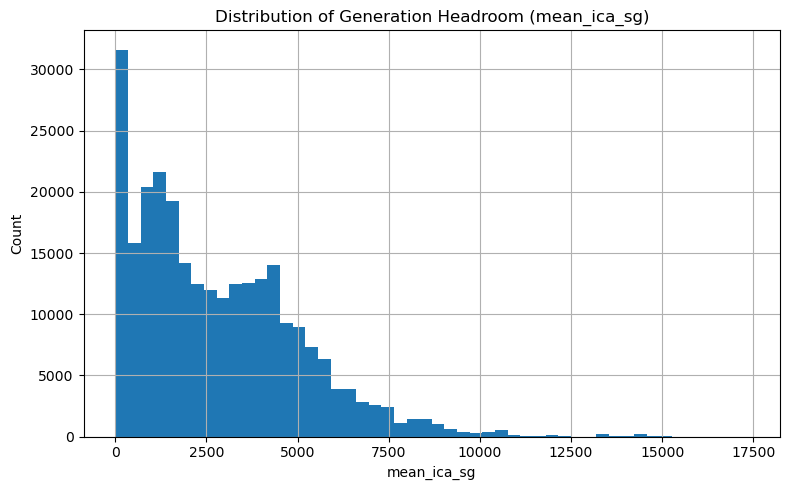


Unique months in final data: [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(6.0), np.float64(7.0), np.float64(8.0), np.float64(9.0), np.float64(10.0), np.float64(11.0), np.float64(12.0)]
Unique hours in final data: [np.float64(0.0), np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(6.0), np.float64(7.0), np.float64(8.0), np.float64(9.0), np.float64(10.0), np.float64(11.0), np.float64(12.0), np.float64(13.0), np.float64(14.0), np.float64(15.0), np.float64(16.0), np.float64(17.0), np.float64(18.0), np.float64(19.0), np.float64(20.0), np.float64(21.0), np.float64(22.0), np.float64(23.0)]


In [25]:
import matplotlib.pyplot as plt


# check feeder_features structure
print("\n=== feeder_features summary ===")
print("Shape (rows, columns):", feeder_features.shape)
print("Columns:", feeder_features.columns.tolist())

print("\nHead of final dataframe:")
display(feeder_features.head())

print("\nInfo:")
feeder_features.info()

# check loadorgen counts
if "loadorgen" in feeder_features.columns:
    print("\nloadorgen value counts:")
    print(feeder_features["loadorgen"].value_counts(dropna=False))

if "mean_ica_sg" in feeder_features.columns:
    print("\nmean_ica_sg summary stats:")
    print(feeder_features["mean_ica_sg"].describe())

# check mean_ica_sg distribution
if "mean_ica_sg" in feeder_features.columns:
    plt.figure(figsize=(8, 5))
    feeder_features["mean_ica_sg"].dropna().hist(bins=50)
    plt.xlabel("mean_ica_sg")
    plt.ylabel("Count")
    plt.title("Distribution of Generation Headroom (mean_ica_sg)")
    plt.tight_layout()
    plt.show()

# check for month/hour coverage
if {"month", "hour"}.issubset(feeder_features.columns):
    print("\nUnique months in final data:", sorted(feeder_features["month"].dropna().unique()))
    print("Unique hours in final data:", sorted(feeder_features["hour"].dropna().unique()))

## Checking spatial coverage of feeder_features data fram
The maps generated below show full coverage of PG&E feeder IDs from the feeder shapefiles, compared with the feeders in our final feeder_features data frame. Comparing te number of feeders in PG&E shapefiles with the feeders present in feeder_features reveals that abbroximately 2/3 of feeders are not in the final data frame. This is likely due to rural feeders not falling within California regions with Zip codes or due to the feeders not falling within one of the climate zones used in the CALMAC load profiles data. Despite this, more than 900 unique feeders are in the final data frame, which will provide enough data to model.We also constructed a heatmap which shows the distribution of feeder congestion across remaining feeders, as calculated by mean_ica_sg. this maps reveals ample spatial distribution of feeders and congestion within the feeder_features data frame, with plenty of distribution across climate zone.

Feeder geometries in shapefile: 3023
Feeders in feeder_features:    989
Feeders with both geometry and ICA: 930


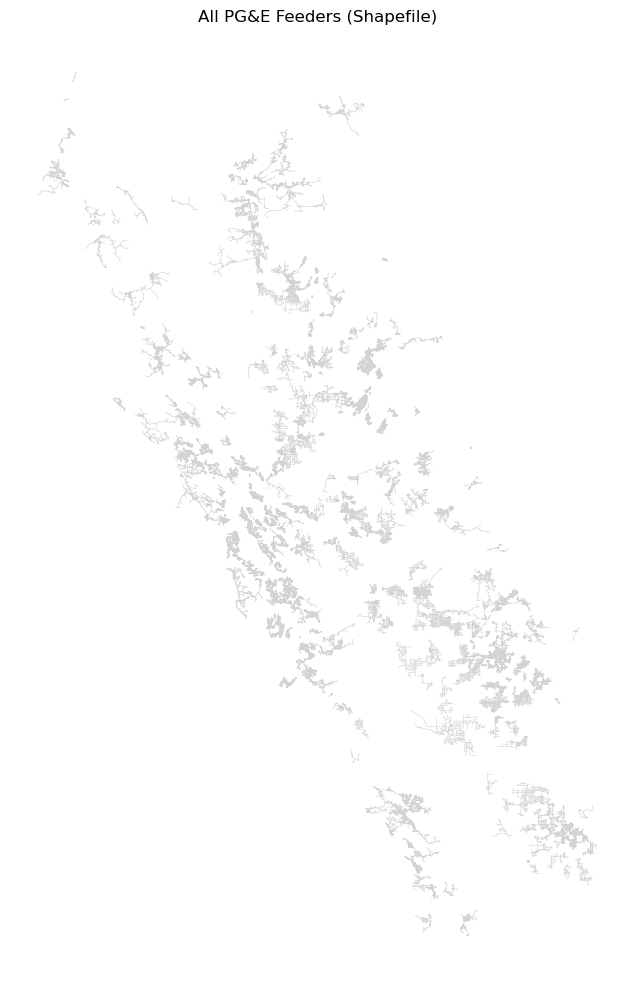

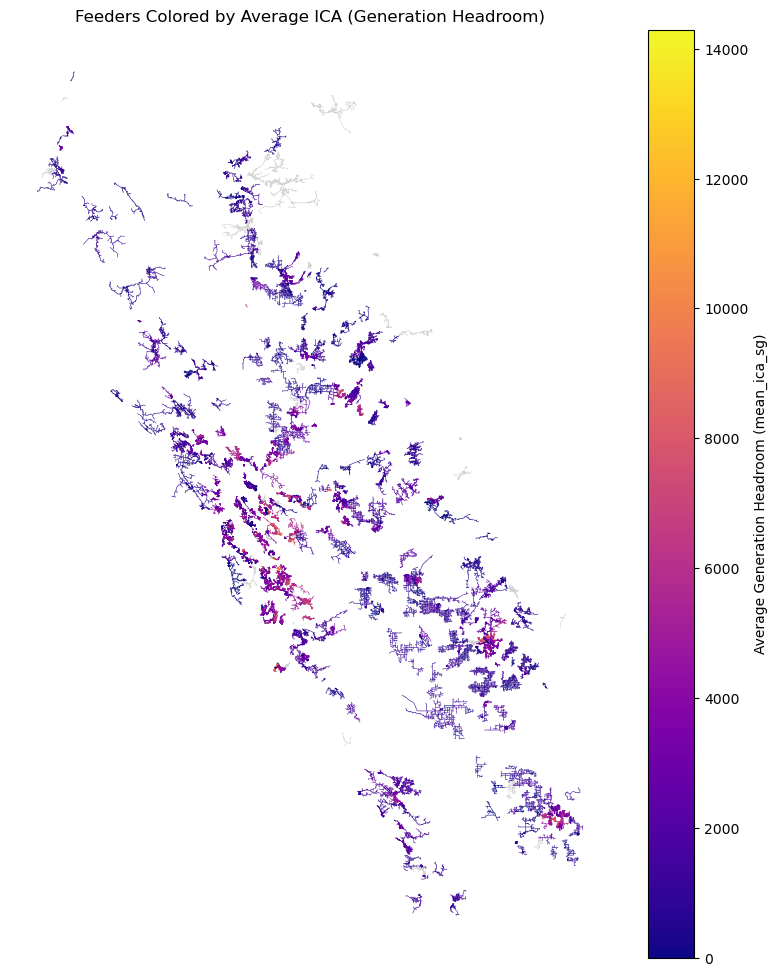

In [26]:


# Check coverage of resulting feeders and distribution of mean_ica_sg (congestion)
# Load feeder shapefile
feeders = gpd.read_file("ica_data/FeederDetail_Voltage.shp")
feeders["feederid"] = normalize_feederid(feeders["feederid"])

# aggregate congestion accross each feeder
if "mean_ica_sg" in feeder_features.columns:
    ff_unique = (
        feeder_features
        .groupby("feederid", as_index=False)["mean_ica_sg"]
        .mean()
    )
else:
    raise ValueError("mean_ica_sg not found in feeder_features; cannot plot ICA heatmap.")

# Merge geometries with ICA summary
feeders_merged = feeders.merge(ff_unique, on="feederid", how="left")

# Coverage diagnostics
n_geom = feeders["feederid"].nunique()
n_ff = feeder_features["feederid"].nunique()
n_with_ica_geom = feeders_merged.loc[
    feeders_merged["mean_ica_sg"].notna(), "feederid"
].nunique()

print(f"Feeder geometries in shapefile: {n_geom}")
print(f"Feeders in feeder_features:    {n_ff}")
print(f"Feeders with both geometry and ICA: {n_with_ica_geom}")

# Map all feeders
fig, ax = plt.subplots(figsize=(8, 10))
feeders.plot(ax=ax, color="lightgray", linewidth=0.4)
ax.set_title("All PG&E Feeders (Shapefile)")
ax.set_axis_off()
plt.tight_layout()
plt.show()

# heat-map congestion
fig, ax = plt.subplots(figsize=(8, 10))
feeders_merged.plot(
    ax=ax,
    column="mean_ica_sg",
    cmap="plasma",
    legend=True,
    legend_kwds={"label": "Average Generation Headroom (mean_ica_sg)"},
    linewidth=0.4,
    missing_kwds={"color": "lightgray", "label": "No ICA data"},
)
ax.set_title("Feeders Colored by Average ICA (Generation Headroom)")
ax.set_axis_off()
plt.tight_layout()
plt.show()

## Forecasting and Prediction Modeling (25 points)

This section is where the rubber meets the road.  In it you must:
1. Explore at least 3 prediction modeling approaches for each prediction question, ranging from the simple (e.g. linear regression, KNN) to the complex (e.g. SVM, random forests, Lasso).  
2. Motivate all your modeling decisions.  This includes parameter choices (e.g., how many folds in k-fold cross validation, what time window you use for averaging your data) as well as model form (e.g., If you use regression trees, why?  If you include nonlinear features in a regression model, why?). 
1. Carefully describe your cross validation and model selection process.  You should partition your data into training and testing data sets.  The training data set is what you use for cross-validation (i.e. you sample from within it to create folds, etc.).  The testing data set is held to the very end of your efforts, and used to compare qualitatively different models (e.g. OLS vs random forests).
4. Very carefully document your workflow.  We will be reading a lot of projects, so we need you to explain each basic step in your analysis.  
5. Seek opportunities to write functions allow you to avoid doing things over and over, and that make your code more succinct and readable. 

#### Prediction model 1: Regression:

##### Motivation and Model Selection:

For this prediction problem, we frame feeder congestion as a continuous regression task at the feeder–month–hour level. The target variable is the available headroom in MW (mean_ica_sg), interpreted as the remaining solar hosting capacity on each feeder at a given month–hour. Our feature set combines relatively static feeder attributes (e.g., voltage class, existing distributed generation, customer mix) with more dynamic temporal and environmental variables (month, hour, system load, and weather). The core goal is to estimate “How much headroom will this feeder have at month–hour?”, so that planners can identify feeders where capacity is tightening over time and evaluate the impacts of future DER or load-growth scenarios.


We explore three main families of regression models that span the complexity spectrum: OLS as a simple linear baseline, regularized linear models (Ridge and Lasso regression), and a Random Forest regressor as a flexible, non-linear ensemble model. To evaluate and select models, we partitioned the data into a training set and a held-out test set using an 80/20 split. The training set is used exclusively for model fitting and cross-validation, if that was included on the model, while the test set is held out until the very end for a one-time comparison of final model performance. All linear models (OLS, Ridge, Lasso) are standardized using StandardScaler so that features are on comparable scales. This is especially important for Ridge and Lasso, whose penalties depend on the scale of the coefficients. The Random Forest model does not use standardization, because tree-based models are inherently scale-invariant.


##### Data Processing and Hyperparameter Tuning:

Within the training data for Ridge, Lasso, and Random Forest models, we use k-fold cross-validation (10-folds) to tune hyperparameters and estimate out-of-sample error. For Ridge and Lasso, we cross-validated to select the α that minimizes the average Root Mean Squared Error (RMSE) across folds. For the Random Forest, we tuned a small set of key hyperparameters—such as the number of trees, maximum depth, and minimum samples per leaf—balancing predictive performance against training time. Our primary selection metric is RMSE, since it has the same units as the target (MW headroom) and penalizes larger errors more strongly, although we also report MAE and R² to provide additional context.

Before fitting models, we performed basic feature screening to improve the potential predictive power of models generated. We restricted the predictor set to numeric variables (excluding the target), identified any strictly categorical columns for potential encoding or exclusion, and then computed pairwise correlations and Variance Inflation Factors (VIF) to flag highly collinear predictors. Predictors with extremely high correlation or VIF values are considered for removal in order to reduce instability in OLS and to make the Ridge and Lasso penalties more meaningful. This preprocessing step is implemented in a short diagnostic script that prints detected categorical variables and VIF-based drop candidates.


Loaded data from outputs/feeder_features_cleaned_PhillipEdits_v2.csv
Shape: (266258, 19)
Columns: ['feederid', 'month', 'hour', 'load', '2024', 'mean_ica_sg', 'Sol Rad (Ly/day)', 'Air Temp (F)', 'Wind Speed (mph)', 'redacted data', 'residential customer count', 'commercial customer count', 'industrial customer count', 'agricultural customer count', 'other customers', 'existing distributed generation (kw)', 'queued distributed generation (kw)', 'total distributed generation (kw)', 'voltage']

Using feature columns:
['feederid', 'month', 'hour', 'load', '2024', 'Sol Rad (Ly/day)', 'Air Temp (F)', 'Wind Speed (mph)', 'residential customer count', 'commercial customer count', 'industrial customer count', 'agricultural customer count', 'other customers', 'existing distributed generation (kw)', 'queued distributed generation (kw)', 'total distributed generation (kw)', 'voltage']

After dropping missing values:
X shape: (235667, 17)
y length: 235667

Columns with ~zero std:
Series([], dtype: 

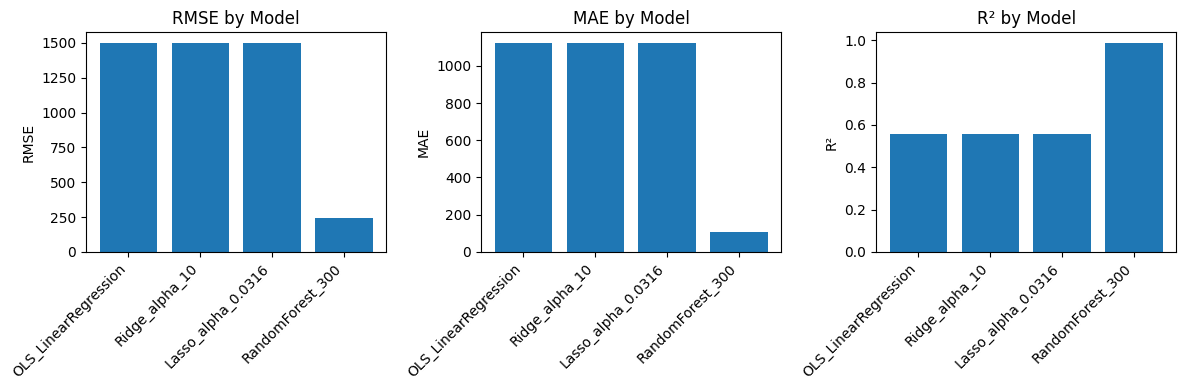


Best model by RMSE: RandomForest_300


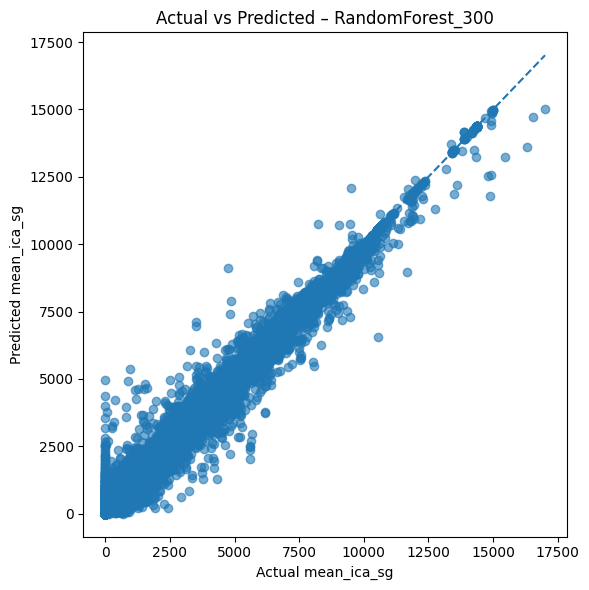

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 1. Load the data
DATA_PATH = "outputs/feeder_features_cleaned_PhillipEdits_v2.csv"

df = pd.read_csv(DATA_PATH)
print(f"Loaded data from {DATA_PATH}")
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

target_col = "mean_ica_sg"
if target_col not in df.columns:
    raise ValueError(f"Target column '{target_col}' not found in dataframe!")


# 2. Set up features/target
numeric_cols = [
    col for col in df.select_dtypes(include=[np.number]).columns
    if col != target_col
]

print("\nUsing feature columns:")
print(numeric_cols)

model_df = df[numeric_cols + [target_col]].dropna()
X = model_df[numeric_cols]
y = model_df[target_col]

print("\nAfter dropping missing values:")
print("X shape:", X.shape)
print("y length:", len(y))


# 3. Train / test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Just to see if anything is basically constant
stds = X.std(numeric_only=True)
print("\nColumns with ~zero std:")
print(stds[stds < 1e-12])


# 4. Preprocessing (standardize numeric features)
preprocessor = ColumnTransformer(
    transformers=[('num', StandardScaler(), numeric_cols)],
    remainder='drop'
)


# 5. Define models
reg_models = {
    "OLS_LinearRegression": Pipeline([
        ('preprocessor', preprocessor),
        ('model', LinearRegression())
    ]),
    "Ridge_alpha_10": Pipeline([
        ('preprocessor', preprocessor),
        ('model', Ridge(alpha=10, random_state=42))
    ]),
    "Lasso_alpha_0.0316": Pipeline([
        ('preprocessor', preprocessor),
        ('model', Lasso(alpha=0.0316, max_iter=10000, random_state=42))
    ]),
    "RandomForest_300": Pipeline([
        ('preprocessor', preprocessor),
        ('model', RandomForestRegressor(
            n_estimators=300,
            random_state=42,
            n_jobs=-1
        ))
    ])
}

# 6. Train, evaluate, store results
print("\n" + "="*50)
print("Prediction Problem 1: Regression – Predict mean_ica_sg (MW headroom)")
print("="*50)

results = []

for name, model in reg_models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print(f"{name}")
    print(f"  RMSE: {rmse:.3f}")
    print(f"  MAE:  {mae:.3f}")
    print(f"  R²:   {r2:.3f}")

    results.append({
        "model": name,
        "rmse": rmse,
        "mae": mae,
        "r2": r2
    })

results_df = pd.DataFrame(results)
print("\nSummary of model performance:")
print(results_df)

# 7. Simple visualizations
plt.figure(figsize=(12, 4))

# RMSE
plt.subplot(1, 3, 1)
plt.bar(results_df["model"], results_df["rmse"])
plt.xticks(rotation=45, ha="right")
plt.title("RMSE by Model")
plt.ylabel("RMSE")

# MAE
plt.subplot(1, 3, 2)
plt.bar(results_df["model"], results_df["mae"])
plt.xticks(rotation=45, ha="right")
plt.title("MAE by Model")
plt.ylabel("MAE")

# R²
plt.subplot(1, 3, 3)
plt.bar(results_df["model"], results_df["r2"])
plt.xticks(rotation=45, ha="right")
plt.title("R² by Model")
plt.ylabel("R²")

plt.tight_layout()
plt.show()

# 8. Actual vs predicted for best model (by RMSE)
best_row = results_df.loc[results_df["rmse"].idxmin()]
best_name = best_row["model"]
print(f"\nBest model by RMSE: {best_name}")

best_model = reg_models[best_name]
y_pred_best = best_model.predict(X_test)

plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_best, alpha=0.6)
min_val = min(y_test.min(), y_pred_best.min())
max_val = max(y_test.max(), y_pred_best.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")
plt.xlabel("Actual mean_ica_sg")
plt.ylabel("Predicted mean_ica_sg")
plt.title(f"Actual vs Predicted – {best_name}")
plt.tight_layout()
plt.show()

Three linear models (ordinary least squares, Ridge, and Lasso regression) produced nearly identical performance, with RMSE values around 1501 MW, MAE values near 1124 MW, and an R² of approximately 0.56, showing that linear relationships explain only about half of the variability in mean MW headroom. In contrast, the Random Forest model performed substantially better, achieving an RMSE of 240 MW, an MAE of 106 MW, and an R² of 0.989. This large improvement indicates that mean feeder headroom is governed by strong nonlinear relationships among load, time, weather, customer composition, and distributed generation, which are effectively captured by the Random Forest but not by linear models.

#### Prediction model 2: Binary Classification:

##### Motivation and Model Selection:

To predict whether a feeder becomes congested (below 1 MW of headroom), we tested a mix of simple and complex models: Logistic Regression (two versions), Linear SVM, KNN, and Random Forest. We wanted to see how far simple linear models could go before switching to more flexible nonlinear approaches:

Logistic Regression (Default, Ridge / L2):

We used logistic regression as our starting baseline model because it is simple and easy to interpret. It allows us to clearly see how each feature is related to congestion risk, which makes it helpful for understanding general trends in the data.

Logistic Regression (C = 10, Weaker Regularization):

This version of logistic regression is a less constrained version of the baseline model. By allowing the model to fit the training data more closely, we tested whether reducing the regularization would improve predictions. 

Support Vector Machine (SVM)

The SVM looks for the best separating boundary between congested and non-congested feeders by maximizing the margin between the two groups. 

Random Forest 

The Random Forest model combines many decision trees to make a final prediction. We included this model because feeder congestion is influenced by interacting physical and behavioral factors, which simple linear models cannot fully represent.

K-Nearest Neighbors (KNN)

The KNN model makes predictions by looking at the most similar past observations and using their outcomes to classify new cases. 

##### Data Processing:

Before training any models, we spent time preparing the data so that all models would be learning from clean, comparable, and reliable inputs. Since our dataset contains a mix of numerical and categorical features (such as weather variables, customer counts, and distributed generation), we first converted all categorical variables into numeric form using one-hot encoding. This step allows the models to interpret categories mathematically rather than as text.

Next, we addressed missing values, which are unavoidable in real-world operational datasets. Instead of discarding large portions of the data, we used median imputation to fill in missing numerical values. 

After splitting the data into training (80%) and testing (20%) sets, we applied standardization only after the split to avoid information leakage. Using StandardScaler, we transformed each numerical feature so that it had a "mean of 0 and a standard deviation of 1", based solely on the training data. This step is especially important for models like Logistic Regression, SVM, and KNN, which are sensitive to differences in feature scale. Without standardization, variables such as distributed generation (measured in thousands of kW) would dominate smaller-scale features like wind speed or temperature, leading to biased learning.



##### Hyperparameter Tuning:

To move beyond purely default model settings, we performed light but principled hyperparameter tuning on our main predictive models. For Logistic Regression, we evaluated two values of the regularization parameter C: the default C = 1, which applies moderate Ridge (L2) regularization to prevent overfitting, and a weaker regularization setting C = 10, which allows the model to fit the data more closely. For the Random Forest, we tuned the number of trees (100 and 200), the maximum tree depth (None, 10, and 20), and the minimum number of samples per leaf (1 and 5) using 3-fold cross-validation on the training set, selecting the configuration that maximized recall for congested feeders. For K-Nearest Neighbors (KNN), we tuned the number of neighbors (5, 10, 15, 20, and 30), again using recall as the selection metric. Smaller values of k capture highly local behavior but are more sensitive to noise, while larger values smooth predictions across broader operating conditions. By selecting k through cross-validation, we ensured that the final KNN model reflects a principled balance between bias and variances. The Linear SVM was evaluated using standard regularization settings to serve as an additional linear baseline for comparison against the nonlinear models.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
)

df = pd.read_csv("outputs/feeder_features_cleaned.csv")

df["congested"] = (df["mean_ica_sg"] < 1000).astype(int)

forbidden_cols = [
    "nominal voltage (kv)", "ZIP_CODE", "loadorgen", "2023",
    "%change", "feederid", "redacted data", "voltage", "mean_ica_sg"
]

cols_to_drop = [c for c in forbidden_cols + ["congested"] if c in df.columns]
X = df.drop(columns=cols_to_drop)
y = df["congested"]

X_encoded = pd.get_dummies(X, drop_first=True)

imputer = SimpleImputer(strategy="median")
X_imputed = imputer.fit_transform(X_encoded)

X_train, X_test, y_train, y_test = train_test_split(
    X_imputed, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

models = {}

logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train, y_train)
models["LogReg_default"] = logreg

logreg_loose = LogisticRegression(C=10, max_iter=1000)
logreg_loose.fit(X_train, y_train)
models["LogReg_C10"] = logreg_loose

svm = LinearSVC()
svm.fit(X_train, y_train)
models["LinearSVM"] = svm

rf_param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_leaf": [1, 5],
}

rf_base = RandomForestClassifier(random_state=42)
rf_grid = GridSearchCV(
    rf_base, rf_param_grid, cv=3, scoring="recall", n_jobs=-1
)
rf_grid.fit(X_train, y_train)
best_rf = rf_grid.best_estimator_
models["RandomForest_Tuned"] = best_rf

print("Best Random Forest params:", rf_grid.best_params_)

knn_param_grid = {"n_neighbors": [5, 10, 15, 20, 30]}
knn_base = KNeighborsClassifier()
knn_grid = GridSearchCV(
    knn_base, knn_param_grid, cv=3, scoring="recall", n_jobs=-1
)
knn_grid.fit(X_train, y_train)
best_knn = knn_grid.best_estimator_
models["KNN_Tuned"] = best_knn

print("Best KNN params:", knn_grid.best_params_)

results = []

for name, clf in models.items():
    y_pred = clf.predict(X_test)
    if hasattr(clf, "predict_proba"):
        y_scores = clf.predict_proba(X_test)[:, 1]
    elif hasattr(clf, "decision_function"):
        y_scores = clf.decision_function(X_test)
    else:
        y_scores = None

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_scores) if y_scores is not None else np.nan

    results.append(
        {"model": name, "accuracy": acc, "precision": prec,
         "recall": rec, "roc_auc": auc}
    )

results_df = pd.DataFrame(results)
print(results_df)

Best Random Forest params: {'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 200}
Best KNN params: {'n_neighbors': 5}
                model  accuracy  precision    recall   roc_auc
0      LogReg_default  0.800477   0.639439  0.423496  0.840412
1          LogReg_C10  0.800458   0.639365  0.423496  0.840411
2           LinearSVM  0.790844   0.636613  0.338628  0.840974
3  RandomForest_Tuned  0.979531   0.965249  0.950583  0.997409
4           KNN_Tuned  0.953992   0.909267  0.902010  0.986140


##### Results Interpretation:

After tuning, the best Random Forest model ended up using 200 trees, with no limit on how deep the trees can grow, and a minimum leaf size of 1. In simple terms, this means the model works best when it is allowed to be very detailed and flexible, rather than forcing it to stay simple. This tells us that feeder congestion depends on fine-grained, local conditions instead of broad averages. Small differences in weather, load, or customer mix can meaningfully change congestion risk, and the Random Forest is capturing that.

For KNN, the best choice was k = 5, meaning the model looks at only the five most similar past situations to make a prediction. This shows that congestion tends to happen under very specific operating conditions, and the most similar historical cases are the most informative. Using more neighbors would smooth things too much and hide these local effects.

When we compare overall performance, the tuned Random Forest clearly performs the best: It gets almost 98% of all predictions correct, and correctly identifies about 95% of truly congested feeders.

The tuned KNN model also performs well, with over 90% recall, showing that local similarity is a strong predictor of congestion. However, it is still less consistent than the Random Forest and more sensitive to noise.

In contrast, the linear models (Logistic Regression and Linear SVM) perform much worse at detecting congestion, missing more than half of actual congestion events. The fact that Logistic Regression performs the same with both C = 1 and C = 10 confirms that the problem is not about tuning — it’s that congestion simply isn’t a linear process.

<Figure size 640x480 with 0 Axes>

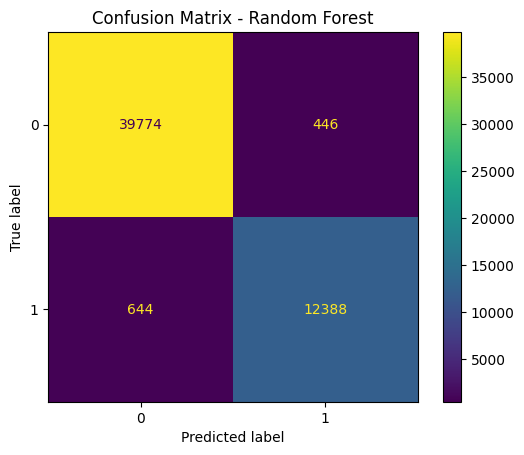

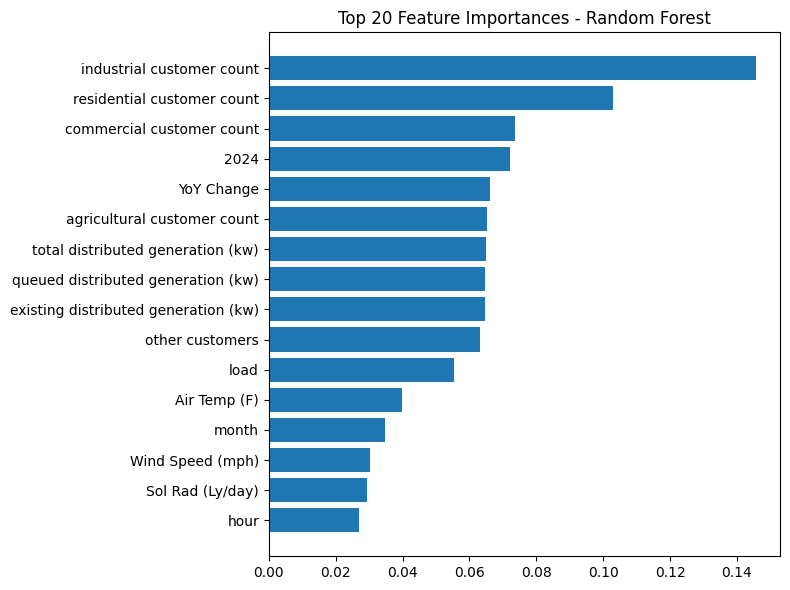

In [ ]:
cm = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])

plt.figure()
disp.plot(values_format='d')
plt.title("Confusion Matrix - Random Forest")
plt.show()

importances = models['RandomForest_Tuned'].feature_importances_
feature_names = X_encoded.columns

idx = np.argsort(importances)[-20:]
top_importances = importances[idx]
top_features = feature_names[idx]

plt.figure(figsize=(8, 6))
plt.barh(top_features, top_importances)
plt.title("Top 20 Feature Importances - Random Forest")
plt.tight_layout()
plt.show()

Since the Random Forest clearly performed the best among all models, we focused our deeper analysis on this model. To better understand both its predictive behavior and practical usefulness, we generated a confusion matrix to examine how well it distinguishes between congested and non-congested feeders in terms of true positives, false positives, true negatives, and false negatives. In addition, we analyzed the feature importance scores produced by the Random Forest to identify which variables contribute most to congestion prediction.

#### Prediction Model 3: Multi-Category Classification:

##### Motivation and Model Selection:

For this prediction problem, we model feeder congestion as a three-tier classification task at the feeder–month–hour level, where the response variable encodes low, medium, and high congestion based on available headroom in MW (e.g., Tier 2 = <1 MW headroom, Tier 1 = 1–5 MW, Tier 0 = >5 MW). Our feature set combines relatively static feeder characteristics (voltage class, customer mix, DER penetration, feeder ID) with more dynamic temporal and environmental variables (month, hour, weather, year indicator). Because the utility ultimately cares about identifying feeders at elevated risk while still having a simple story about why a feeder is risky, we deliberately chose a modeling sequence that moves from interpretable, low-capacity models to more flexible, higher-capacity methods.

We explore three primary modeling approaches that span this complexity spectrum: multinomial logistic regression (softmax) as a linear, baseline classifier; a single decision tree as a non-linear but still highly interpretable model; and a random forest as a more complex ensemble method capable of capturing higher-order interactions and non-linearities. Logistic regression serves as our “workhorse baseline” because it is fast, relatively robust, and produces coefficients that can be directly interpreted as feature effects on the log-odds of each congestion tier. The decision tree relaxes the linearity assumption and can represent threshold-based rules (e.g., “if voltage is low and industrial customers are high, then Tier 2”) that are closer to how engineers reason about feeders. Finally, the random forest aggregates many de-correlated trees to reduce variance and overfitting, making it a natural candidate for improved predictive performance on a large dataset with potential interactions between customer mix, DER, and temporal variables. We do not prioritize methods like KNN or SVM here: KNN scales poorly to ~260k observations and many features, and SVMs (especially non-linear kernels) tend to be computationally intensive and less interpretable at this scale, offering less added value than tree ensembles for our use case.


##### Data Processing and Hyperparameter Tuning:

To evaluate these models, we partition the data into a training set and a held-out test set (roughly 80/20) using a stratified split by congestion tier so that the class imbalance in the full data (Tier 1 much more common than Tier 0 and Tier 2) is preserved in both subsets. Model selection and hyperparameter tuning are performed only on the training data, using k-fold cross-validation (e.g., 5-fold stratified CV) to compare candidate configurations for each model while avoiding overfitting to a single split. For example, for the decision tree we vary parameters like maximum depth and minimum samples per leaf; for logistic regression we consider the strength of regularization; and for the random forest we tune the number of trees and tree depth. Because our main concern is performance across all three congestion tiers, and not just the majority class, we focus on macro-averaged F1 as our primary cross-validation metric, while also reporting overall accuracy and the per-class precision/recall on the held-out test set for interpretability.

Throughout the workflow, we structure our code to be modular and reusable, both to keep it readable and to avoid repeating the same evaluation logic for each model. In practice, this means writing helper functions that: (1) take a scikit-learn model plus training and test data, (2) fit the model, (3) generate predictions, (4) compute and print accuracy, macro F1, and a full classification report, and (5) optionally extract and display feature importances or coefficients where available. This functional structure makes it easy to swap in different models or hyperparameter settings while preserving a consistent evaluation pipeline, and it keeps the modeling narrative transparent: define the prediction question, choose a family of models for clear reasons, tune them via cross-validation on the training set, and only then compare their final performance on the untouched test set.


In [ ]:
# 1. Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    f1_score,
)

# 2. Load data
csv_path = "outputs/feeder_features_cleaned_PhillipEdits_v2.csv"
df = pd.read_csv(csv_path)

response_col = "mean_ica_sg"
df = df.dropna(subset=[response_col])

# 3. Define features and create 3-class target variable
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [c for c in numeric_cols if c != response_col]

X = df[feature_cols]
headroom = df[response_col]

# Define 3 risk tiers
conditions = [
    headroom > 5000.0,
    (headroom >= 1000.0) & (headroom <= 5000.0),
    headroom < 1000.0,
]
choices = [0, 1, 2]
y_tier = np.select(conditions, choices).astype(int) 

print("\nTier distribution:")
print(pd.Series(y_tier).value_counts().sort_index())

# 4. Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_tier,
    test_size=0.2,
    random_state=42,
    stratify=y_tier,  #ensure train and test sets are balanced 
)

# 5. Helper function for printing metrics
def print_multiclass_metrics(y_true, y_pred, label=""):
    acc = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average="macro")

    print(f"\n{label}")
    print(f"Accuracy: {acc:.3f}")  #float 3 decimals
    print(f"Macro F1: {macro_f1:.3f}")
    print("Classification report:")
    print(classification_report(y_true, y_pred))

# 6. Model Training
# (A) Logistic Regression 
log_model = make_pipeline(
    SimpleImputer(strategy="median"),  # Use median imputation to handle missing numeric values robustly.
    StandardScaler(),  # Scale features because logistic regression performs best on standardized data.
    LogisticRegression(
        multi_class="multinomial",   # Use true multinomial (softmax) for multi-class prediction instead of one-vs-rest.
        solver="lbfgs",   # LBFGS is stable and efficient for multinomial logistic regression.
        max_iter=500,  # Increase iterations to ensure the model converges on a large dataset.
        random_state=42   # Fix random seed for reproducible model behavior.
    ),
)

# (B) Decision Tree
dt_model = make_pipeline(
    SimpleImputer(strategy="median"), # Fill missing numeric values with the median to avoid losing data.
    StandardScaler(),  # Included for pipeline consistency; trees are scale-invariant.
    DecisionTreeClassifier(
        max_depth=5,  # Limit tree depth to prevent overfitting and improve generalization.
        min_samples_leaf=50,  # Require at least 50 samples per leaf to smooth out noisy splits.
        random_state=42, # Fix random seed for reproducible tree structure.
    ),
)

# (C) Random Forest
rf_model = make_pipeline(
    SimpleImputer(strategy="median"),
    StandardScaler(),
    RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1,
    ),
)

results = []

results.append({
    "Model": "Logistic Regression",
    "Accuracy": accuracy_score(y_test, y_pred_log),
    "Precision": precision_score(y_test, y_pred_log, average="macro"),
    "Recall": recall_score(y_test, y_pred_log, average="macro"),
    "Macro F1": f1_score(y_test, y_pred_log, average="macro")
})

results.append({
    "Model": "Decision Tree",
    "Accuracy": accuracy_score(y_test, y_pred_dt),
    "Precision": precision_score(y_test, y_pred_dt, average="macro"),
    "Recall": recall_score(y_test, y_pred_dt, average="macro"),
    "Macro F1": f1_score(y_test, y_pred_dt, average="macro")
})

results.append({
    "Model": "Random Forest",
    "Accuracy": accuracy_score(y_test, y_pred_rf),
    "Precision": precision_score(y_test, y_pred_rf, average="macro"),
    "Recall": recall_score(y_test, y_pred_rf, average="macro"),
    "Macro F1": f1_score(y_test, y_pred_rf, average="macro")
})

results_df = pd.DataFrame(results)
print(results_df.round(3))


Tier distribution:
0     42459
1    158640
2     65159
Name: count, dtype: int64
                 Model  Accuracy  Precision  Recall  Macro F1
0  Logistic Regression     0.696      0.681   0.608     0.634
1        Decision Tree     0.732      0.747   0.624     0.662
2        Random Forest     0.970      0.968   0.967     0.968


This table compares overall performance across the three models.
The random forest dramatically outperforms both logistic regression and the decision tree, achieving very high accuracy and macro-F1, while the other two models show moderate performance and struggle with class imbalance.


<Figure size 600x500 with 0 Axes>

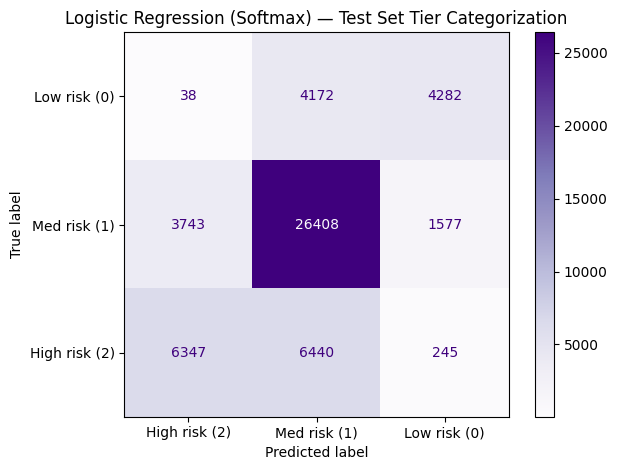

<Figure size 600x500 with 0 Axes>

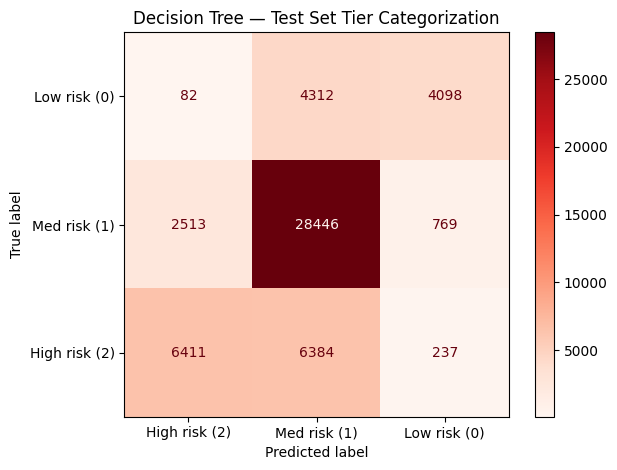

<Figure size 600x500 with 0 Axes>

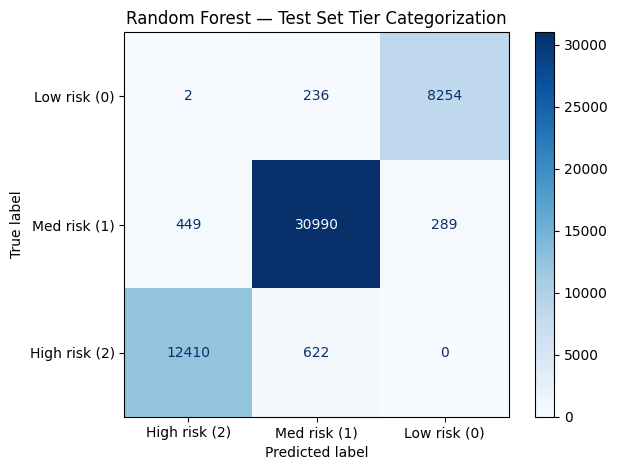

In [ ]:
# 7. Visualizations - here we plot our results as confusion matrices
tier_labels = ["Low risk (0)", "Med risk (1)", "High risk (2)"]

# Logistic Regression Confusion Matrix 
cm_log = confusion_matrix(y_test, y_pred_log, labels=[0, 1, 2])
# Reverse the columns for x-axis reversal
cm_log_reversed = cm_log[:, ::-1]

# Create custom display with reversed labels for x-axis
disp_log = ConfusionMatrixDisplay(confusion_matrix=cm_log_reversed, 
                                  display_labels=tier_labels[::-1])

plt.figure(figsize=(6, 5))
disp_log.plot(cmap="Purples", values_format="d")
plt.title("Logistic Regression (Softmax) — Test Set Tier Categorization")

# Manually set the y-axis labels in the correct order
ax = plt.gca()
ax.set_yticklabels(tier_labels)
ax.set_xticklabels(tier_labels[::-1])  # Keep x-axis reversed

plt.tight_layout()
plt.show()

# Decision Tree Confusion Matrix 
cm_dt = confusion_matrix(y_test, y_pred_dt, labels=[0, 1, 2])
cm_dt_reversed = cm_dt[:, ::-1]

disp_dt = ConfusionMatrixDisplay(confusion_matrix=cm_dt_reversed, 
                                 display_labels=tier_labels[::-1])

plt.figure(figsize=(6, 5))
disp_dt.plot(cmap="Reds", values_format="d")
plt.title("Decision Tree — Test Set Tier Categorization")

ax = plt.gca()
ax.set_yticklabels(tier_labels)
ax.set_xticklabels(tier_labels[::-1])

plt.tight_layout()
plt.show()

# Random Forest Confusion Matrix 
cm_rf = confusion_matrix(y_test, y_pred_rf, labels=[0, 1, 2])
cm_rf_reversed = cm_rf[:, ::-1]

disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf_reversed, 
                                 display_labels=tier_labels[::-1])

plt.figure(figsize=(6, 5))
disp_rf.plot(cmap="Blues", values_format="d")
plt.title("Random Forest — Test Set Tier Categorization")

ax = plt.gca()
ax.set_yticklabels(tier_labels)
ax.set_xticklabels(tier_labels[::-1])

plt.tight_layout()
plt.show()




Logistic regression provides a solid linear baseline but struggles with Tier 0 and Tier 2 due to its limited capacity to model non-linear patterns. It performs best on the majority Tier 1 class, with noticeably lower recall for high-risk feeders.

The decision tree improves on logistic regression by capturing non-linear thresholds, especially boosting Tier 1 performance, but still misses many Tier 0 and Tier 2 cases. Its overall performance is moderate, reflecting the limitations of using a shallow, interpretable model on a complex classification task.

The random forest achieves excellent performance across all tiers, with high precision, recall, and F1, indicating strong ability to capture complex interactions in the data. Its consistently high scores suggest far better predictive power, though it may risk overfitting compared to simpler models.


## Resource Allocation and Conclusions (20 points)
In this section you must relate your modeling and forecasting results to your original prediction question.  You must:
1. Address a resource allocation question.  What do the answers mean? What advice would you give a decision maker on the basis of your results?  How might they allocate their resources differently with the results of your model?  Why should the reader care about your results?  *To get full marks you must provide both a qualitative and quantitative analysis.*
2. Discuss caveats and / or reasons your results might be flawed.  No model is perfect, and understanding a model's imperfections is extremely important for the purpose of knowing how to interpret your results.  Often, we know the model output is wrong but we can assign a direction for its bias.  This helps to understand whether or not your answers are conservative.  

Shoot for 500-1000 words for this section.

# ER 131 Data sources (delete this cell from your final project)
Many of these links just take you to the main landing page for the data.  Note a number of these links also lead you to many different data sets.

## Energy data
1. [Integrated Circuit Analysis (ICA) load data from Pacific Gas & Electric (PG&E) company](https://www.pge.com/en/about/doing-business-with-pge/interconnections/distributed-resource-planning-data-and-maps.html)
2. [Cool Climate -- spatially resolved energy and carbon emissions data](https://coolclimate.berkeley.edu/data)
3. [Residential Energy Consumption Survey](https://www.eia.gov/consumption/residential/)
4. [California Grid Operator market data](http://oasis.caiso.com/mrioasis/logon.do)
5. [California Energy Commission data archives -- many different sources of data describing energy production and use in California](https://www.energy.ca.gov/data-reports)
5. [Alternative fuels data center](https://afdc.energy.gov/)


## Transportation data
1. [California Air Resources Board’s Fleet Database](https://arb.ca.gov/emfac/fleet-db)
2. [EV Charging Stations Source](https://www.energy.ca.gov/data-reports/energy-insights/zero-emission-vehicle-and-charger-statistics)
3. [California vehicle fuel type counts by zip code (there are more years available)](https://www.dmv.ca.gov/portal/uploads/2020/04/MotorVehicleFuelTypes_ZipCode_102018.pdf)
4. [Census Bureau means of transport](https://data.census.gov/cedsci/table?q=MEANS%20OF%20TRANSPORTATION%20TO%20WORK%20BY%20VEHICLES&tid=ACSDT1Y2018.B08141&hidePreview=false)
4. [Census Bureau number of commuters](https://data.census.gov/cedsci/table?q=vehicle&g=0400000US06&tid=ACSDT1Y2019.B08015&hidePreview=true)
4. [Atlas EV Hub](https://www.atlasevhub.com/)

## Environmental data 
1. [Climate Model prediction data](https://cal-adapt.org/data/download/)
2. [Water Quality Portal](https://www.waterqualitydata.us/wqp_description/)
2. [Methane Plumes Derived from AVIRIS-NG over Point Sources across California, 2016-2017](https://daac.ornl.gov/cgi-bin/dsviewer.pl?ds_id=1727)
3. [EPA AirNow pollution data](https://www.epa.gov/outdoor-air-quality-data)
	a. ["Pre-generated" files here](https://aqs.epa.gov/aqsweb/airdata/download_files.html)
4. [California Department of Water Resources Data Exchange Portal](http://cdec.water.ca.gov/index.html)
5. [NOAA Climate data online](https://www.ncdc.noaa.gov/cdo-web/)
5. [Methane emitting facilities from US Dept of Commerce](https://daac.ornl.gov/NACP/guides/NACP_Vista_CA_CH4_Inventory.html)
4. [California Air Resources Board Emissions Inventory](https://ww3.arb.ca.gov/ei/maps/2017statemap/cntymap.htm)
4. [Groundwater level measurements](https://data.cnra.ca.gov/dataset/periodic-groundwater-level-measurements)
4. [California Enviroscreen -- includes pollution data by census block](https://oehha.ca.gov/calenviroscreen/report/calenviroscreen-30)
5. [NEON Ecological Forecasting Challenge -- provides pre-processed target data for aquatic communities, carbon & water fluxes, tick populations, phenology, and beetle abundance](https://ecoforecast.org/efi-rcn-forecast-challenges/) *Ask Jessica if you have questions about using this data.*


## Geographic and census data
1. [California County boundaries](https://data.ca.gov/dataset/ca-geographic-boundaries/resource/b0007416-a325-4777-9295-368ea6b710e6)
2. [Another CA county boundary dataset](https://catalog.data.gov/dataset/tiger-line-shapefile-2016-state-california-current-county-subdivision-state-based)
3. [Census data](https://data.census.gov/cedsci/)
	a. Note these data can be accessed by an API.  [This](https://jtleider.github.io/censusdata/) codebase can help you access the API, which is [here](https://www.census.gov/data/developers.html)
2. [Census Data from the US Census Bureau's ACS Demographic and Housing Estimates](https://data.census.gov/cedsci/table?q=United%20States&t=Counts,%20Estimates,%20and%20Projections%3AFamilies%20and%20Living%20Arrangements%3AHousing%3AHousing%20Units%3APopulation%20Total%3APopulations%20and%20People%3ARace%20and%20Ethnicity&g=0400000US06,06%24160000&tid=ACSDP5Y2018.DP05)
3. [Labor Force Data](https://www.labormarketinfo.edd.ca.gov/data/industry-employment-and-unemployment-rates-for-counties.html)
4. [USGS National Land Cover Database](https://www.mrlc.gov/data?f%5B0%5D=category%3Aland%20cover&f%5B1%5D=year%3A2016)
4. [California Enviroscreen -- includes demographic data by census block, derived from census data](https://oehha.ca.gov/calenviroscreen/report/calenviroscreen-40)
5. [USAID Demographic and Health Survey Data](https://dhsprogram.com/) 

## Other
1. [USDA Cow Density Data](https://www.nass.usda.gov/Charts_and_Maps/Cattle/)
